## TG Classificação ESG Random Forest

#### Lendo DF filtrado

In [7]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo_filtrado = r'C:\Users\lucas\TG - ESG\Datasets\base_filtrada.csv'

# Ler o arquivo
df_filtrado = pd.read_csv(caminho_arquivo_filtrado)

df_filtrado.head()

,address1,city,state,zip,country,phone,website,industry,industrykey,industrydisp,...,exdividenddate,fiveyearavgdividendyield,earningsquarterlygrowth,lastsplitfactor,lastsplitdate,lastdividendvalue,lastdividenddate,earningsgrowth,dividenddate,esg_risk_level
0,47281 Bayside Parkway,Fremont,CA,94538,United States,707 774 7000,https://www.enphase.com,Solar,solar,Solar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200 South Wilcox Drive,Kingsport,TN,37662,United States,423 229 2000,https://www.eastman.com,Specialty Chemicals,specialty-chemicals,Specialty Chemicals,...,1.749773e+09,3.22,0.103,2:1,1.317686e+09,0.83,1.741910e+09,0.130,1.751933e+09,Medium
2,30 Frank Lloyd Wright Drive,Ann Arbor,MI,48105,United States,734 930 3030,https://ir.dominos.com,Restaurants,restaurants,Restaurants,...,1.749773e+09,1.06,0.215,NaN,NaN,1.74,1.741910e+09,0.301,1.751242e+09,Medium
3,3311 East Old Shakopee Road,Minneapolis,MN,55425,United States,952 853 8100,https://www.dayforce.com,Software - Application,software-application,Software - Application,...,NaN,NaN,1.099,NaN,NaN,NaN,NaN,1.250,NaN,NaN
4,2000 16th Street,Denver,CO,80202,United States,720-631-2100,https://www.davita.com,Medical Care Facilities,medical-care-facilities,Medical Care Facilities,...,NaN,NaN,-0.320,2:1,1.378685e+09,NaN,NaN,-0.245,NaN,Medium


#### Lendo DF tratato

In [3]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo = r'C:\Users\lucas\TG - ESG\Datasets\base_tratada.csv'

# Ler o arquivo
df = pd.read_csv(caminho_arquivo)

df.head()

,fulltimeemployees,auditrisk,boardrisk,compensationrisk,shareholderrightsrisk,overallrisk,payoutratio,beta,trailingpe,forwardpe,...,dividendyield,fiveyearavgdividendyield,earningsquarterlygrowth,lastdividendvalue,earningsgrowth,esg_risk_level,regularmarketdayrange_min,regularmarketdayrange_max,fiftytwoweekrange_min,fiftytwoweekrange_max
0,2781.0,6.0,7.0,9.0,10.0,9.0,0.0000,1.801,36.366970,10.830601,...,0.00,0.00,0.249626,0.00,0.226513,NaN,37.600,39.97,37.59,141.63
1,14000.0,7.0,8.0,7.0,6.0,7.0,0.4178,1.304,10.259872,9.257472,...,4.12,3.22,0.103000,0.83,0.130000,Medium,79.535,80.77,70.90,114.50
2,6400.0,5.0,5.0,8.0,8.0,7.0,0.3595,1.161,27.547590,27.235262,...,1.45,1.06,0.215000,1.74,0.301000,Medium,476.520,481.93,396.06,538.44
3,9600.0,8.0,10.0,8.0,7.0,9.0,0.0000,1.172,357.687500,25.895927,...,0.00,0.00,1.099000,0.00,1.250000,NaN,56.885,57.73,47.08,82.69
4,76000.0,8.0,2.0,3.0,3.0,1.0,0.0000,1.141,13.722940,12.261757,...,0.00,0.00,-0.320000,0.00,-0.245000,Medium,136.500,138.63,131.76,179.60


## Código pra modelo de Random Forest

### Deixando o código aleatório rodando com 1000 valores de seeds únicos

### Aplicando StratifiedKFold 
técnica de validação cruzada estratificada muito usada em classificações, especialmente quando há desequilíbrio entre as classes

### Aplicando SMOTE (Synthetic Minority Over-Sampling) 
crianco novas amostras sintéticas da classe High com base em seus vizinhos, permitindo que o modelo veja mais exemplos e aprenda padrões melhores, isso está embutido embutido na validação cruzada (StratifiedKFold) para resolver isso

### Aplicando class_weight='balanced' 
A fim de balancear os pesos de cada classe na execução do algoritmo

### Parâmetros utilizados com base na execução do GridSeachCV
Que busca os parâmetros ótimos para execução do modelo

In [34]:
import numpy as np
import pandas as pd
import random
from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE

# 1. Separa os dados com target conhecido
df_known = df[df['esg_risk_level'].notna()].copy()

# 2. Define X e y
X = df_known.drop(columns=['esg_risk_level', 'ticker'])

# Verifica se ainda existe algum NaN em X
if X.isna().any().any():
    print("Ainda existem NaNs em X — favor verificar!")

# One-hot encode para variáveis categóricas
X = pd.get_dummies(X)

# Codifica o target
y = df_known['esg_risk_level']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
label_indices = list(range(len(class_names)))
y_binarized_all = label_binarize(y_encoded, classes=label_indices)

# 3. Número de seeds
n_seeds = 1000
seed_list = random.sample(range(1_000_000), n_seeds)

# 4. Armazenar métricas
all_reports = []
all_y_true_list = []
all_y_pred_list = []
all_y_proba_list = []
all_tickers_test = []

accuracy_list = []
balanced_acc_list = []
mcc_list = []
kappa_list = []
roc_auc_list = []
split_ranges = []

for rand_seed in seed_list:
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=rand_seed)
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    all_tickers = []

    for train_idx, test_idx in cv.split(X, y_encoded):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        tickers_test = df_known.iloc[test_idx]['ticker'].values
        all_tickers.extend(tickers_test)
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        smote = SMOTE(random_state=rand_seed, k_neighbors=3)
        X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            max_features='sqrt',
            min_samples_leaf=1,
            min_samples_split=5,
            max_depth=10,
            random_state=rand_seed
        )

        clf.fit(X_resampled, y_resampled)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)

    # Cálculo de métricas
    accuracy = accuracy_score(all_y_true, all_y_pred)
    balanced_acc = balanced_accuracy_score(all_y_true, all_y_pred)
    mcc = matthews_corrcoef(all_y_true, all_y_pred)
    kappa = cohen_kappa_score(all_y_true, all_y_pred)

    # Binariza os labels para ROC AUC macro
    try:
        y_true_bin = label_binarize(all_y_true, classes=label_indices)
        roc_auc = roc_auc_score(y_true_bin, all_y_proba, average='macro', multi_class='ovr')
    except ValueError:
        roc_auc = np.nan  # Se houver erro por ausência de classes

    report = classification_report(
        all_y_true,
        all_y_pred,
        labels=label_indices,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    all_reports.append((report, accuracy))
    #all_y_true_list.append(all_y_true)
    #all_y_pred_list.append(all_y_pred)
    #all_y_proba_list.append(all_y_proba)
    #all_tickers_test.append(all_tickers)

    start_idx = len(all_y_true_list)
    all_y_true_list.extend(all_y_true)
    all_y_pred_list.extend(all_y_pred)
    all_y_proba_list.extend(all_y_proba)
    all_tickers_test.extend(all_tickers)
    end_idx = len(all_y_true_list)
    split_ranges.append((start_idx, end_idx))


    # Armazena métricas agregadas
    accuracy_list.append(accuracy)
    balanced_acc_list.append(balanced_acc)
    mcc_list.append(mcc)
    kappa_list.append(kappa)
    roc_auc_list.append(roc_auc)

# 5. Agregação de métricas por classe
metrics = ['precision', 'recall', 'f1-score']
target_labels = list(class_names) + ['macro avg', 'weighted avg']
metric_matrix = defaultdict(list)

for rep, acc in all_reports:
    for label in target_labels:
        for metric in metrics:
            value = rep.get(label, {}).get(metric, 0.0)
            metric_matrix[(label, metric)].append(value)

# 6. Impressão das métricas por classe
print("=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===")
for label in target_labels:
    print(f"\nClasse '{label}':")
    for metric in metrics:
        values = metric_matrix[(label, metric)]
        mean = np.mean(values)
        std = np.std(values)
        print(f"  {metric}: média = {mean:.4f}, desvio padrão = {std:.4f}")

# 7. Métricas globais agregadas
def print_global_metric(name, values):
    print(f"{name:<25} média = {np.mean(values):.4f} | desvio = {np.std(values):.4f}")

print("\n=== MÉTRICAS GLOBAIS ADICIONAIS ===")
print_global_metric("Acurácia", accuracy_list)
print_global_metric("Balanced Accuracy", balanced_acc_list)
print_global_metric("Matthews CorrCoef", mcc_list)
print_global_metric("Cohen's Kappa", kappa_list)
print_global_metric("ROC AUC (macro)", [v for v in roc_auc_list if not np.isnan(v)])

# 8. Seleção da execução mais próxima da média de f1-score
avg_f1 = {label: np.mean(metric_matrix[(label, 'f1-score')]) for label in class_names}
min_diff = float('inf')
best_idx = -1

for i, (rep, acc) in enumerate(all_reports):
    total_diff = sum(
        abs(rep.get(label, {}).get('f1-score', 0.0) - avg_f1[label]) for label in class_names
    )
    if total_diff < min_diff:
        min_diff = total_diff
        best_idx = i

# 9. Matriz de confusão da execução mais representativa
print("\n=== MATRIZ DE CONFUSÃO (execução mais próxima da média) ===")
#cm = confusion_matrix(all_y_true_list[best_idx], all_y_pred_list[best_idx])
start, end = split_ranges[best_idx]
cm = confusion_matrix(all_y_true_list[start:end], all_y_pred_list[start:end])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df)

# 10. Acurácia desta execução
print(f"\nAcurácia desta execução: {accuracy_list[best_idx]:.4f}")

=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===

Classe 'High':
  precision: média = 0.2857, desvio padrão = 0.0567
  recall: média = 0.2162, desvio padrão = 0.0461
  f1-score: média = 0.2450, desvio padrão = 0.0480

Classe 'Low':
  precision: média = 0.6413, desvio padrão = 0.0167
  recall: média = 0.6859, desvio padrão = 0.0250
  f1-score: média = 0.6627, desvio padrão = 0.0177

Classe 'Medium':
  precision: média = 0.5929, desvio padrão = 0.0221
  recall: média = 0.5892, desvio padrão = 0.0272
  f1-score: média = 0.5908, desvio padrão = 0.0213

Classe 'macro avg':
  precision: média = 0.5066, desvio padrão = 0.0238
  recall: média = 0.4971, desvio padrão = 0.0199
  f1-score: média = 0.4995, desvio padrão = 0.0214

Classe 'weighted avg':
  precision: média = 0.5774, desvio padrão = 0.0173
  recall: média = 0.5875, desvio padrão = 0.0173
  f1-score: média = 0.5812, desvio padrão = 0.0170

=== MÉTRICAS GLOBAIS ADICIONAIS ===
Acurácia                  média = 0.5875 | desvio = 0.017

### Código para salvar variaveis 

In [35]:
import joblib  # mais eficiente que pickle para grandes arrays

# Cria dicionário com todos os resultados relevantes
rf_results = {
    'clf': clf,  # salva o modelo treinado da última execução
    'class_names': class_names,
    'label_indices': label_indices,
    'X': X,
    'y_encoded': y_encoded,
    'le': le,  # LabelEncoder
    'all_y_true_list': all_y_true_list,
    'all_y_pred_list': all_y_pred_list,
    'all_y_proba_list': all_y_proba_list,
    'all_tickers_test': all_tickers_test,
    'split_ranges': split_ranges,
    'accuracy_list': accuracy_list,
    'balanced_acc_list': balanced_acc_list,
    'mcc_list': mcc_list,
    'kappa_list': kappa_list,
    'roc_auc_list': roc_auc_list,
    'metric_matrix': dict(metric_matrix),  # converte defaultdict para dict
    'best_idx': best_idx
}

# Salva em um arquivo
joblib.dump(rf_results, "rf_results.pkl")
print("✅ Resultados salvos em 'rf_results.pkl'")


✅ Resultados salvos em 'rf_results.pkl'


### Código para ler variáveis

In [5]:
import joblib

# Carrega os resultados salvos
rf_results = joblib.load("rf_results.pkl")

# Recupera os elementos
clf = rf_results['clf']
class_names = rf_results['class_names']
label_indices = rf_results['label_indices']
X = rf_results['X']
y_encoded = rf_results['y_encoded']
le = rf_results['le']
all_y_true_list = rf_results['all_y_true_list']
all_y_pred_list = rf_results['all_y_pred_list']
all_y_proba_list = rf_results['all_y_proba_list']
all_tickers_test = rf_results['all_tickers_test']
split_ranges = rf_results['split_ranges']
accuracy_list = rf_results['accuracy_list']
balanced_acc_list = rf_results['balanced_acc_list']
mcc_list = rf_results['mcc_list']
kappa_list = rf_results['kappa_list']
roc_auc_list = rf_results['roc_auc_list']
metric_matrix = rf_results['metric_matrix']
best_idx = rf_results['best_idx']

print("✅ Resultados carregados com sucesso")


✅ Resultados carregados com sucesso


### Curva ROC

#### A curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade discriminativa do modelo — ou seja, o quanto ele consegue diferenciar entre classes corretamente.

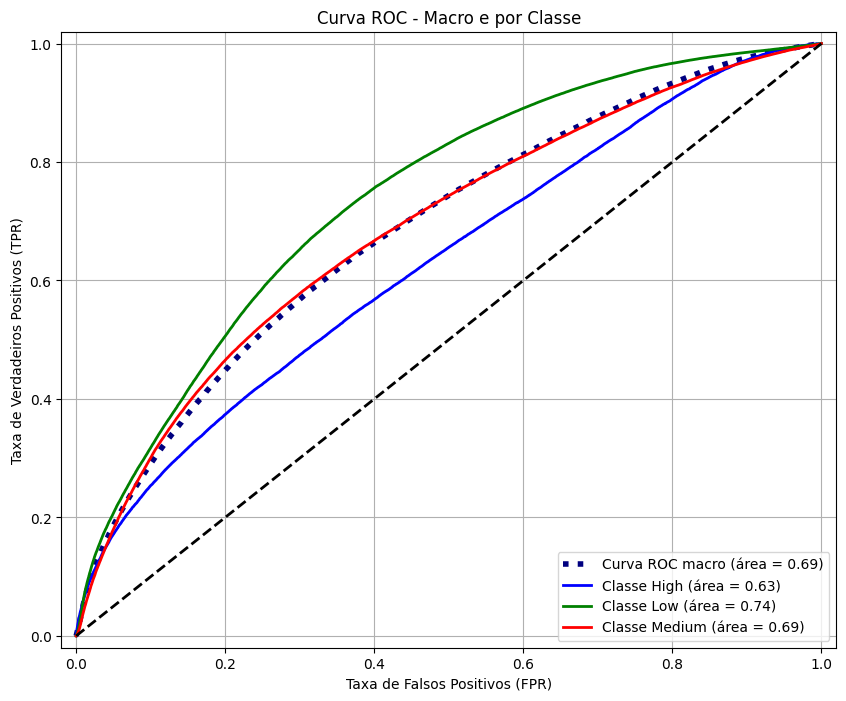

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar os rótulos para curva ROC multiclasse
y_true_bin = label_binarize(all_y_true_list, classes=label_indices)
n_classes = y_true_bin.shape[1]

# Calcula ROC e AUC para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], [p[i] for p in all_y_proba_list])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Curva ROC Macro
# Agregando todos os pares FPR e TPR
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot da curva ROC macro e individual
plt.figure(figsize=(10, 8))

# Macro
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Curva ROC macro (área = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

# Por classe
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (área = {roc_auc[i]:.2f})')

# Gráfico base
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Macro e por Classe')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Matriz de Confusão

#### Ajuda a interpretar onde o modelo está acertando ou errando na predição

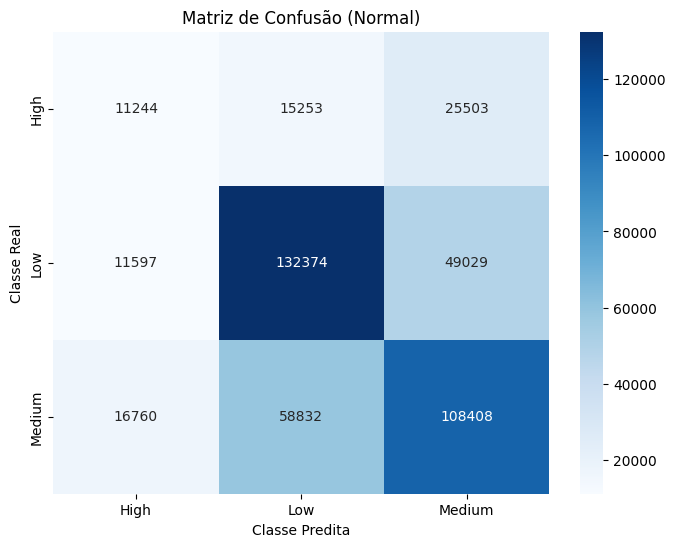

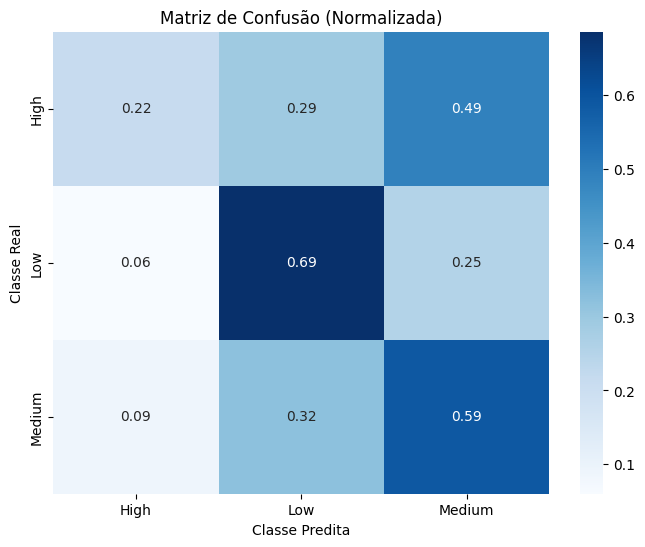

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matriz de confusão
cm = confusion_matrix(all_y_true_list, all_y_pred_list)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Função para plotar
def plot_confusion_matrix(cm, classes, title, cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if cm.dtype==float else "d", 
                cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()

# Matriz normal
plot_confusion_matrix(cm, class_names, title="Matriz de Confusão (Normal)")

# Matriz normalizada
plot_confusion_matrix(cm_normalized, class_names, title="Matriz de Confusão (Normalizada)")


### Precision-Recall Curve por classe

#### A curva Precision-Recall (PR) é uma ferramenta usada para avaliar o desempenho de classificadores, especialmente em problemas com classes desbalanceadas, como é o caso da predição de risco ESG.
#### A curva PR mostra a relação entre precision e recall à medida que o limiar de decisão do modelo é variado.

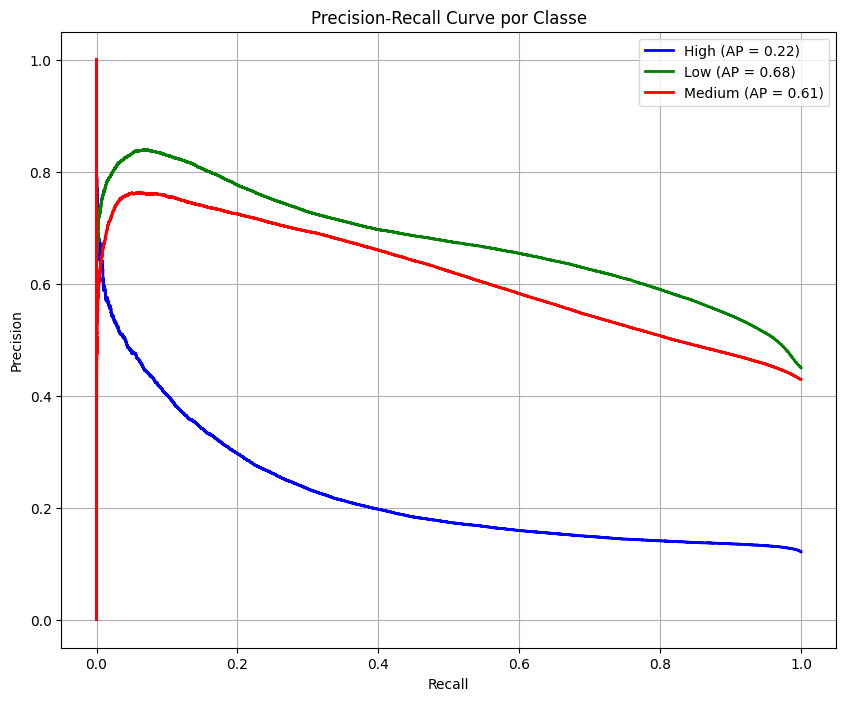

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Binarizar rótulos para multiclasse
y_true_bin = label_binarize(all_y_true_list, classes=label_indices)
n_classes = y_true_bin.shape[1]

# Plot das curvas Precision-Recall
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    # if color == 'red':
    #     continue
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        [p[i] for p in all_y_proba_list]
    )
    avg_prec = average_precision_score(y_true_bin[:, i], [p[i] for p in all_y_proba_list])
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{class_names[i]} (AP = {avg_prec:.2f})')

# Gráfico base
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve por Classe')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


### Vendo importância das features

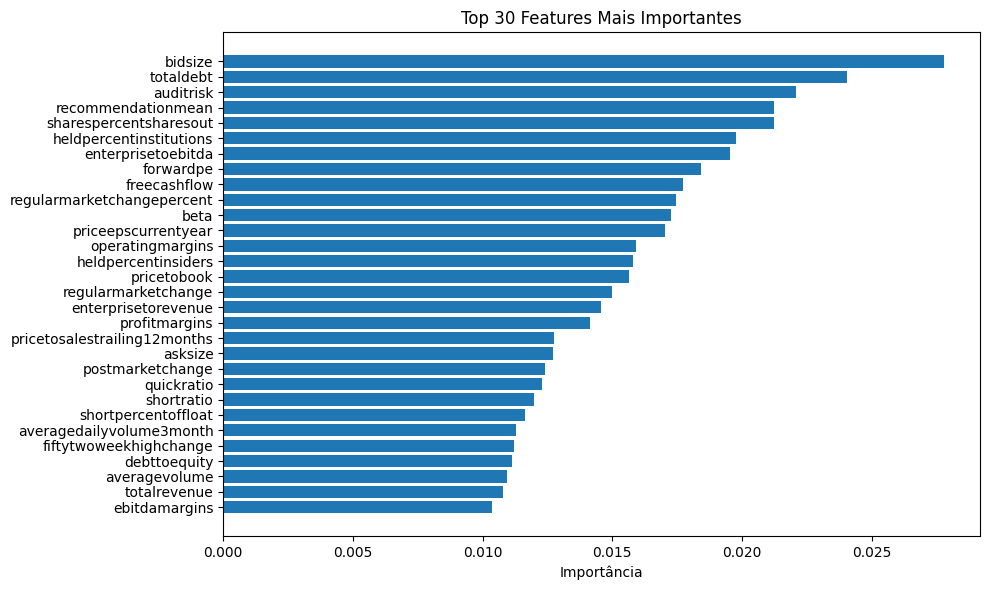

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Após treinar o RandomForestClassifier (com SMOTE)
importances = clf.feature_importances_
feature_names = X.columns

# Cria DataFrame com importâncias
feat_imp5 = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Visualiza as top 20
plt.figure(figsize=(10, 6))
plt.barh(feat_imp5['feature'][:30][::-1], feat_imp5['importance'][:30][::-1])
plt.xlabel('Importância')
plt.title('Top 30 Features Mais Importantes')
plt.tight_layout()
plt.show()

In [41]:
feat_imp5

,feature,importance
16,bidsize,0.027783
53,totaldebt,0.024035
1,auditrisk,0.022071
48,recommendationmean,0.021237
31,sharespercentsharesout,0.021236
33,heldpercentinstitutions,0.019756
45,enterprisetoebitda,0.019517
9,forwardpe,0.018404
62,freecashflow,0.017714
68,regularmarketchangepercent,0.017445


### 📊 Top 30 Features Mais Importantes – Significado e Relevância ESG

| **Feature**                      | **Significado / Interpretação**                                                              | **Relevância para ESG**                                                                 |
|----------------------------------|-----------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------|
| `bidSize`                        | Volume de ordens de compra no mercado                                                        | Indicador de liquidez e interesse; pode refletir confiança do mercado nas práticas ESG. |
| `totalDebt`                      | Dívida total da empresa                                                                      | Reflete risco financeiro e qualidade da governança (pilar G).                           |
| `auditRisk`                      | Risco associado à auditoria                                                                  | Diretamente ligado à governança corporativa.                                             |
| `recommendationMean`            | Recomendação média de analistas (quanto menor, melhor)                                       | Pode refletir confiança do mercado e percepção ESG.                                      |
| `sharesPercentSharesOut`        | Percentual de ações em circulação                                                            | Relacionado à estrutura acionária e transparência.                                       |
| `heldPercentInstitutions`       | Percentual de ações detidas por instituições                                                 | Alta participação institucional pode indicar conformidade com práticas ESG.              |
| `enterpriseToEbitda`            | Valuation baseado em EBITDA                                                                  | Indica sustentabilidade do lucro e eficiência operacional.                              |
| `forwardPE`                      | Preço/Lucro projetado                                                                        | Reflete expectativas de crescimento, possivelmente afetadas por ações ESG.              |
| `freeCashflow`                   | Fluxo de caixa livre                                                                          | Medida de saúde financeira e capacidade de investir em iniciativas ESG.                 |
| `regularMarketChangePercent`    | Variação percentual diária do preço da ação                                                  | Pode refletir reações do mercado a eventos ou notícias ESG.                             |
| `beta`                           | Medida de risco relativo ao mercado                                                          | Alta volatilidade pode indicar maior exposição a riscos ESG e reputacionais.            |
| `priceToCurrentYearEarnings`    | Preço da ação dividido pelos lucros esperados no ano                                         | Relaciona-se com expectativa de retorno e valorização.                                   |
| `operatingMargins`              | Margem operacional                                                                            | Empresas com margens saudáveis têm mais espaço para práticas sustentáveis.              |
| `heldPercentInsiders`           | Percentual de ações nas mãos de executivos                                                   | Pode indicar conflitos de interesse ou alinhamento de longo prazo.                      |
| `priceToBook`                   | Preço da ação sobre valor contábil                                                           | Valuation tradicional, pode indicar percepção de valor tangível.                        |
| `regularMarketChange`           | Variação absoluta do preço da ação                                                           | Complementa a análise de volatilidade e reação a riscos.                                |
| `enterpriseToRevenue`           | Valuation sobre receita                                                                      | Alta relação pode sinalizar expectativas altas e sensibilidade a falhas ESG.            |
| `profitMargins`                 | Margem líquida de lucro                                                                      | Sustentabilidade dos lucros no longo prazo, condição para práticas ESG.                 |
| `priceToSalesTrailing12Months`  | Valuation sobre receita dos últimos 12 meses                                                 | Reforça avaliação de desempenho recente.                                                 |
| `askSize`                        | Volume de ordens de venda                                                                    | Relacionado à liquidez e interesse de mercado.                                           |
| `postMarketChange`              | Variação do preço no pós-mercado                                                            | Pode refletir reações imediatas a eventos de reputação ESG.                             |
| `quickRatio`                    | Liquidez imediata (ativos líquidos / passivos de curto prazo)                                | Indicador de saúde financeira.                                                          |
| `shortRatio`                    | Volume vendido a descoberto em relação ao volume médio diário                               | Sinal de desconfiança dos investidores.                                                  |
| `shortPercentOfFloat`           | Proporção das ações em circulação vendidas a descoberto                                     | Pode indicar percepção negativa, inclusive por razões ESG.                              |
| `averageDailyVolume3Month`      | Volume médio de negociação nos últimos 3 meses                                               | Medida de liquidez e atenção institucional.                                              |
| `fiftyTwoWeekHighChange`        | Distância até o maior preço nos últimos 12 meses                                             | Proxy de performance de mercado no período.                                              |
| `debtToEquity`                  | Relação dívida / patrimônio líquido                                                         | Alta alavancagem indica risco financeiro e governança fraca.                            |
| `averageVolume`                 | Volume médio de negociação                                                                   | Similar à anterior, pode refletir visibilidade e interesse.                              |
| `totalRevenue`                  | Receita total                                                                                 | Empresas maiores costumam ser mais cobradas por responsabilidade ESG.                   |
| `ebitdaMargins`                 | Margem EBITDA                                                                                 | Indicador de eficiência operacional e sustentabilidade financeira.                      |


### Aplicando SHAP (Shapley Additive explanations) por classificação para interpretar as decisões do modelo 

#### SHAP (SHapley Additive exPlanations) é uma técnica de interpretação de modelos baseada na teoria dos jogos de Shapley. Ele atribui a cada feature uma contribuição quantitativa para a previsão de um determinado exemplo, permitindo entender:

#### -Quais variáveis mais influenciaram o modelo.

#### -Em que direção elas atuaram (aumentaram ou diminuíram a chance de determinada classe).

#### -Quão sensível o modelo é às variações dessas variáveis.

shap_values.shape: (143, 97, 3)
🔵 Classe 'High'


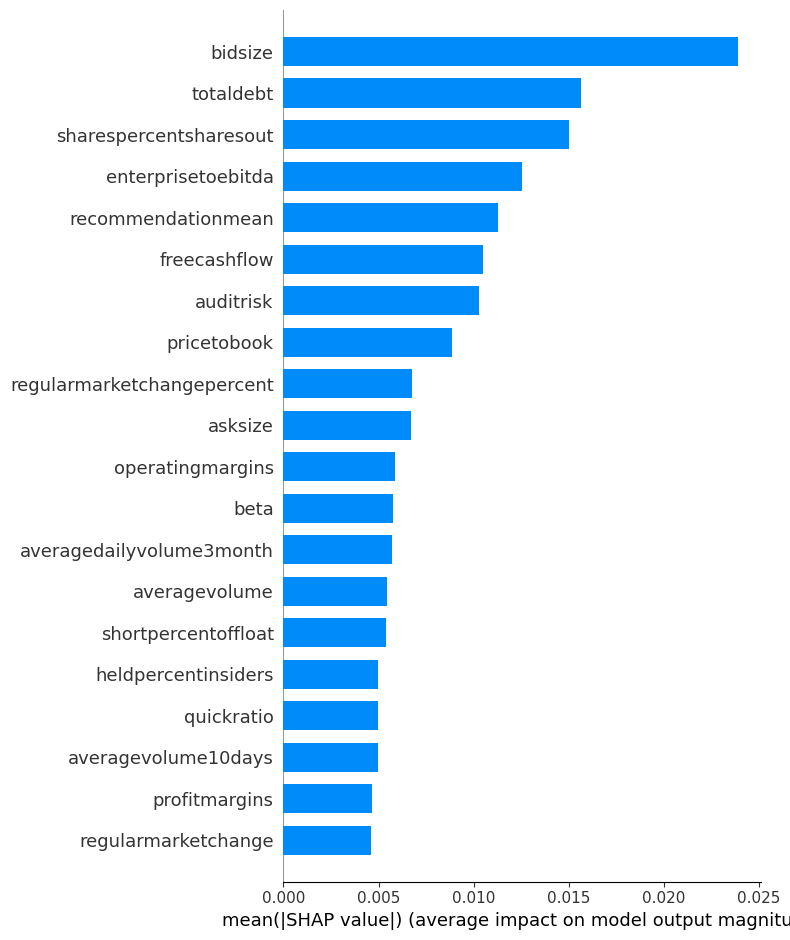

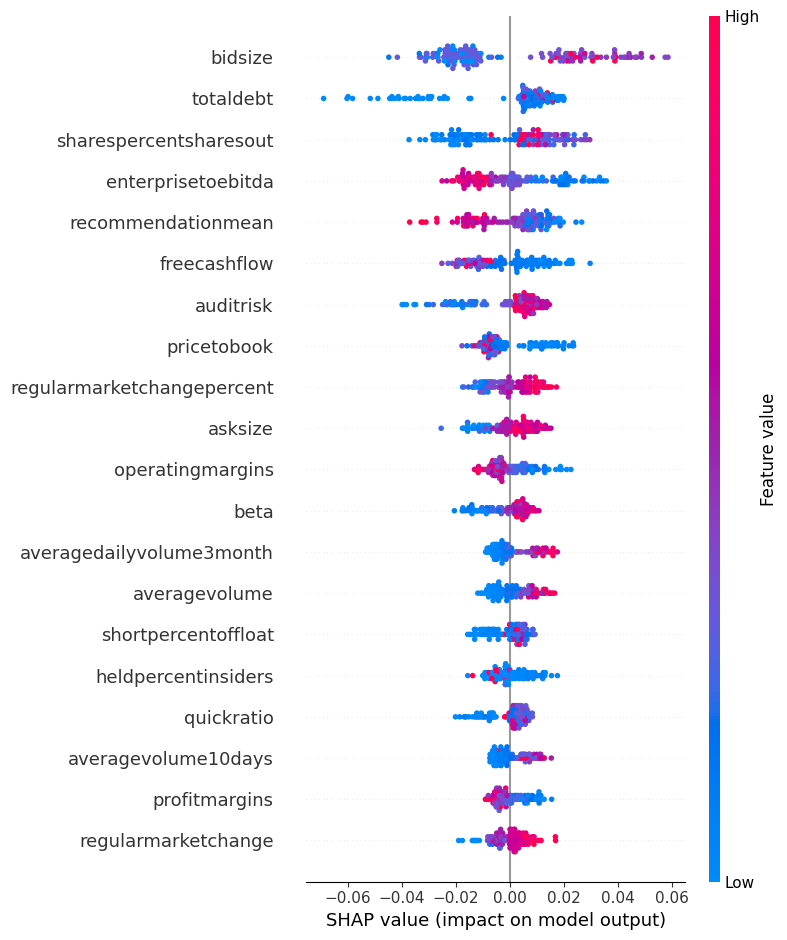

🟠 Classe 'Medium'


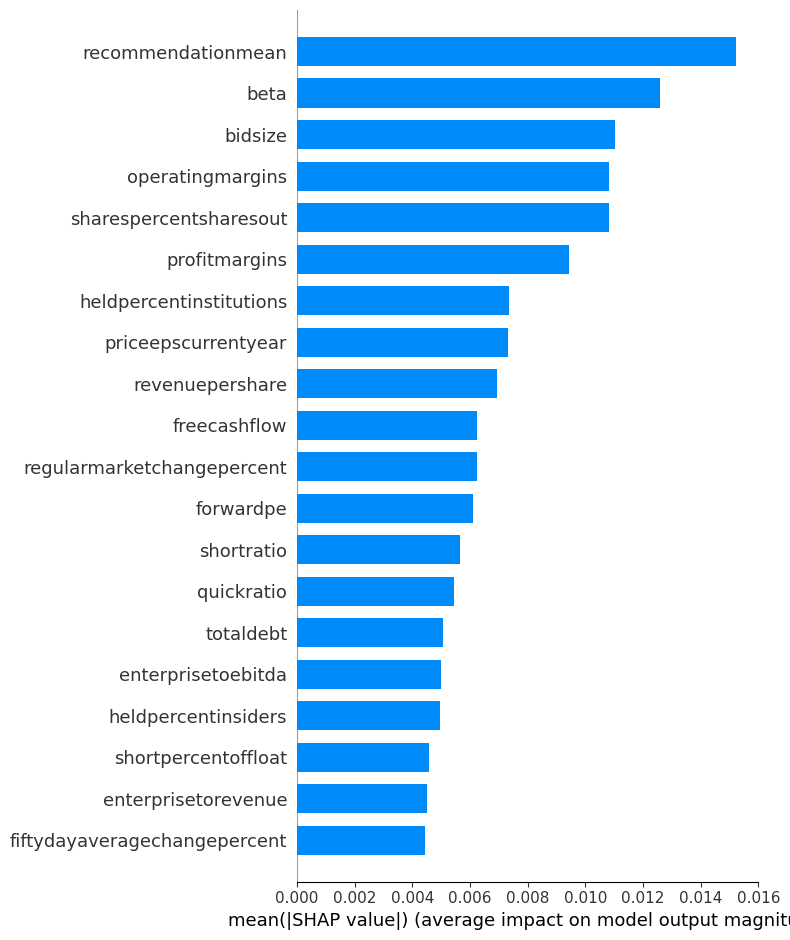

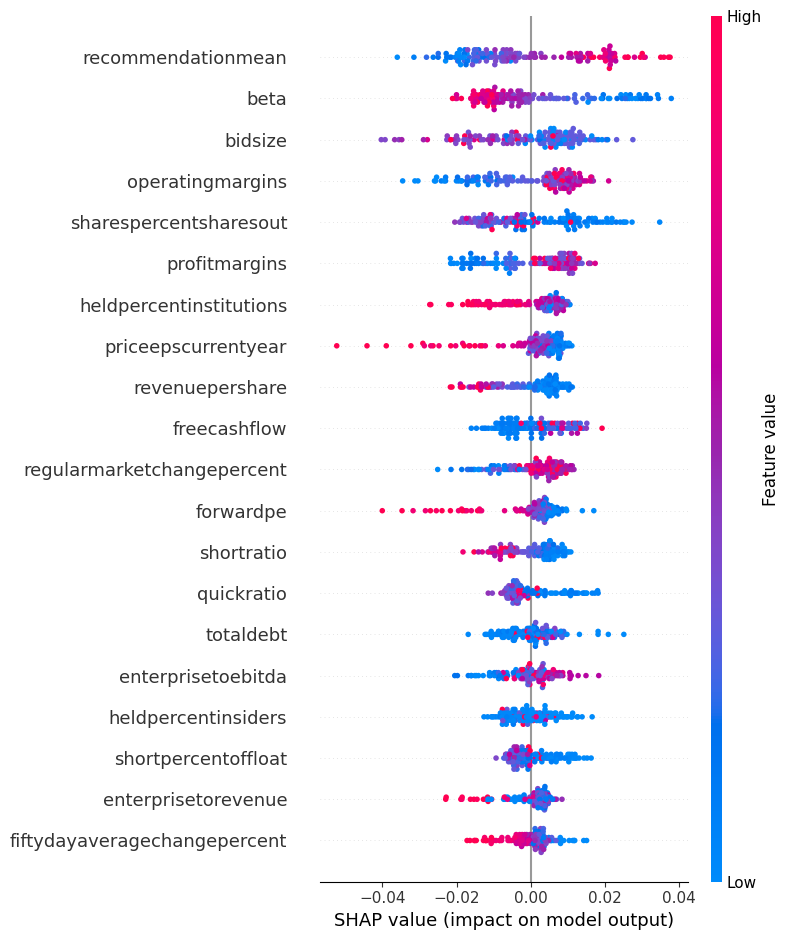

🟢 Classe 'Low'


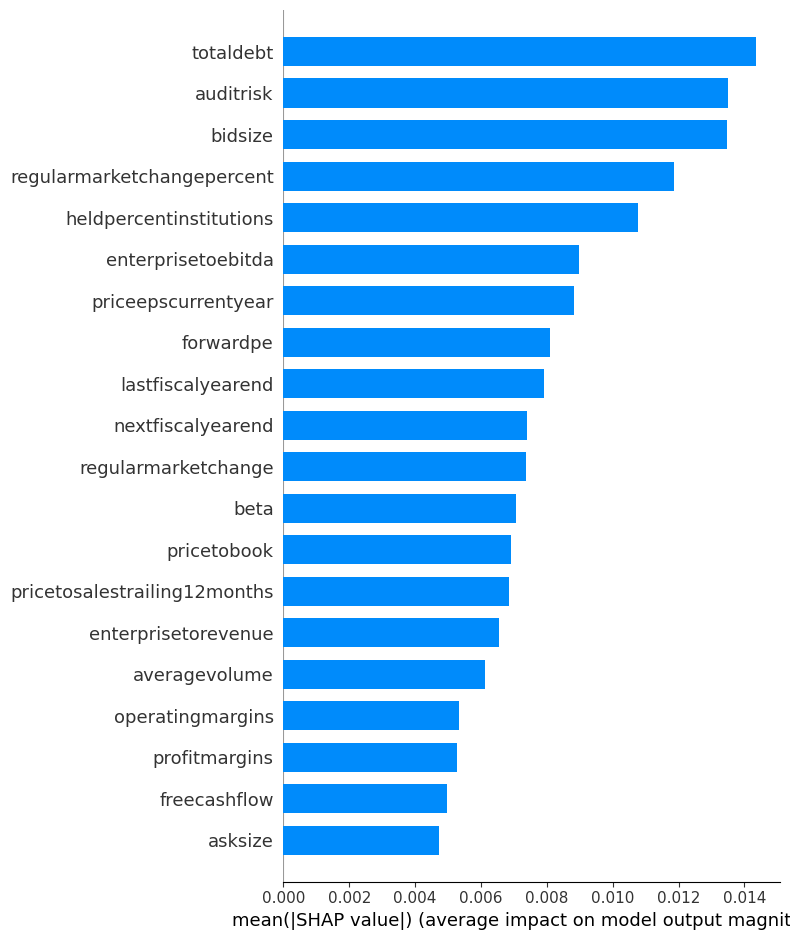

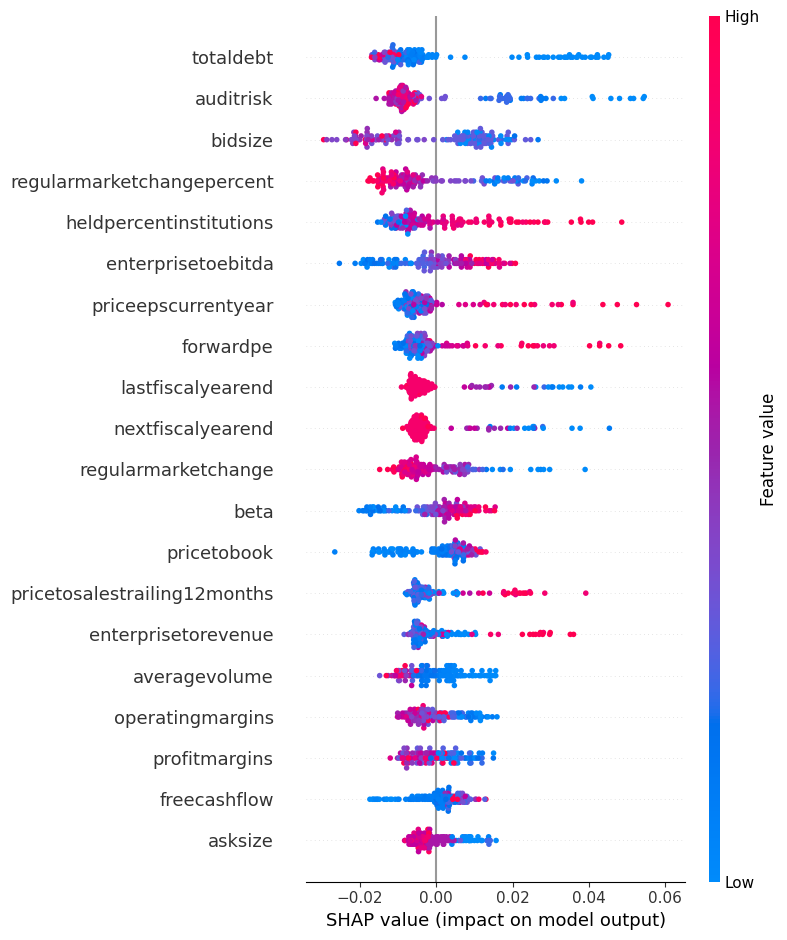

In [42]:
import shap

# Garante alinhamento das features
X_shap = pd.DataFrame(X_test.values, columns=clf.feature_names_in_)

# Usa o SHAP Explainer genérico
explainer = shap.Explainer(clf, X_shap)

# Calcula os SHAP values com aditividade desligada
shap_values = explainer(X_shap, check_additivity=False)

# Confirma formato
print("shap_values.shape:", shap_values.values.shape)  # Esperado: (n_samples, n_features, n_classes)

# Define índices das classes
class_list = list(le.classes_)
high_index = class_list.index('High')
medium_index = class_list.index('Medium')
low_index = class_list.index('Low')

# 🔵 Classe High
print("🔵 Classe 'High'")
shap.summary_plot(shap_values.values[:, :, high_index], X_shap, plot_type="bar")
shap.summary_plot(shap_values.values[:, :, high_index], X_shap)

# 🟠 Classe Medium
print("🟠 Classe 'Medium'")
shap.summary_plot(shap_values.values[:, :, medium_index], X_shap, plot_type="bar")
shap.summary_plot(shap_values.values[:, :, medium_index], X_shap)

# 🟢 Classe Low
print("🟢 Classe 'Low'")
shap.summary_plot(shap_values.values[:, :, low_index], X_shap, plot_type="bar")
shap.summary_plot(shap_values.values[:, :, low_index], X_shap)


### Calculando métricas por setor

Relatórios por subgrupos (“slice metrics”) são recomendados em avaliação de modelos para identificar disparidades de desempenho entre segmentos (ex.: setores GICS), o que pode sinalizar viés ou drift de dados (ver Mitchell et al., Model Cards for Model Reporting, FAT 2019; Barocas, Hardt & Narayanan, Fairness and ML, 2019). Em ESG, isso é especialmente relevante porque a distribuição das classes e variáveis explicativas varia por setor, afetando base rates e métricas agregadas.

In [43]:
from sklearn.metrics import classification_report
import pandas as pd

# Constrói DataFrame com resultados
df_resultados = pd.DataFrame({
    'ticker': all_tickers_test,
    'y_true': all_y_true_list,
    'y_pred': all_y_pred_list
})

# Faz o merge com o dataframe original que contém os setores
df_sector = pd.merge(df_resultados, df_filtrado[['ticker', 'sectorkey']], on='ticker', how='left')

# Calcula métricas por sectorkey
sector_reports = {}
for sector, group in df_sector.groupby('sectorkey'):
    if group['y_true'].nunique() < 2:
        continue  # Evita erros em setores com apenas uma classe
    report = classification_report(
        group['y_true'],
        group['y_pred'],
        output_dict=True,
        zero_division=0
    )
    sector_reports[sector] = {
        'support': len(group),
        'accuracy': report['accuracy'],
        'precision_macro': report['macro avg']['precision'],
        'recall_macro': report['macro avg']['recall'],
        'f1_macro': report['macro avg']['f1-score'],
        'precision_weighted': report['weighted avg']['precision'],
        'recall_weighted': report['weighted avg']['recall'],
        'f1_weighted': report['weighted avg']['f1-score']
    }

# Converte para DataFrame e exibe
df_sector_metrics = pd.DataFrame.from_dict(sector_reports, orient='index').sort_values(by='support', ascending=False)

print(df_sector_metrics)

                        support  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted
financial-services        63000  0.607238         0.423156      0.400065  0.406536            0.619020         0.607238     0.606602
technology                63000  0.682968         0.333461      0.336483  0.332275            0.727596         0.682968     0.703348
industrials               58000  0.430362         0.345045      0.381834  0.332503            0.397890         0.430362     0.384217
healthcare                53000  0.611679         0.436616      0.420371  0.424305            0.645429         0.611679     0.622362
consumer-cyclical         51000  0.557353         0.404365      0.374321  0.388388            0.597661         0.557353     0.576265
consumer-defensive        33000  0.536303         0.408555      0.410005  0.407278            0.570149         0.536303     0.551538
real-estate               28000  0.931679         0.321027      0.322

### 🔍 Análise de Métricas por Setor Econômico (Modelo de Classificação de Risco ESG)

A tabela apresenta a performance do modelo Random Forest por setor, considerando métricas macro (não ponderadas) e weighted (ponderadas).

#### ✅ Destaques Positivos:
- **Real Estate** teve o melhor desempenho geral (f1-weighted = 0.93), indicando previsões muito assertivas, possivelmente devido à dominância de uma única classe.
- **Technology** e **Healthcare** também tiveram bons desempenhos ponderados (f1-weighted > 0.66), embora o modelo ainda tenha dificuldades nas classes minoritárias (baixa f1-macro).
- **Utilities** teve desempenho equilibrado entre métricas macro e weighted, sugerindo bom funcionamento do modelo para diferentes classes.

#### ⚠️ Setores com Desempenho Mediano:
- `Financial Services`, `Consumer Defensive` e `Consumer Cyclical` apresentaram f1-weighted entre 0.53 e 0.66. O modelo ainda mostra viés para a classe mais frequente nesses setores.

#### ❌ Setores Críticos:
- **Basic Materials** e **Energy** apresentaram os piores f1-macro e f1-weighted, indicando que o modelo praticamente falha em distinguir corretamente entre as classes ESG nesses setores.
- **Communication Services** e **Industrials** também apresentaram desempenho abaixo do esperado.

📌 Conclusão: a performance do modelo varia consideravelmente entre os setores

### Matriz de Confusão por setor

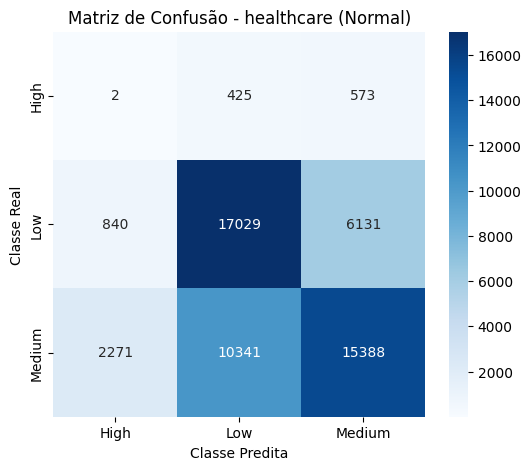

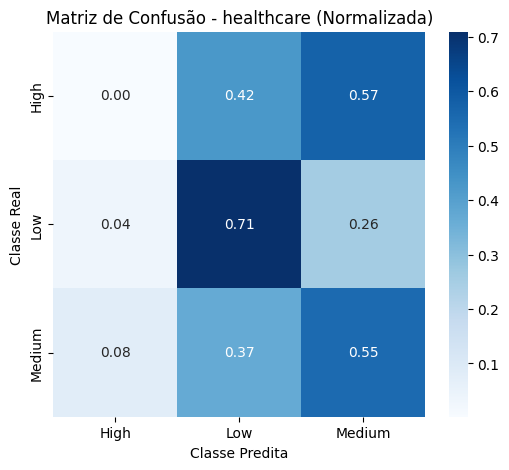

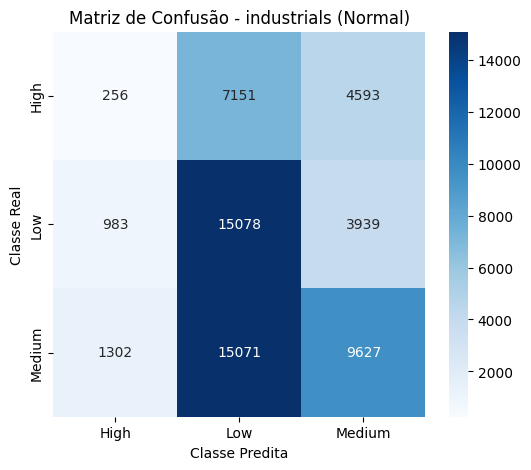

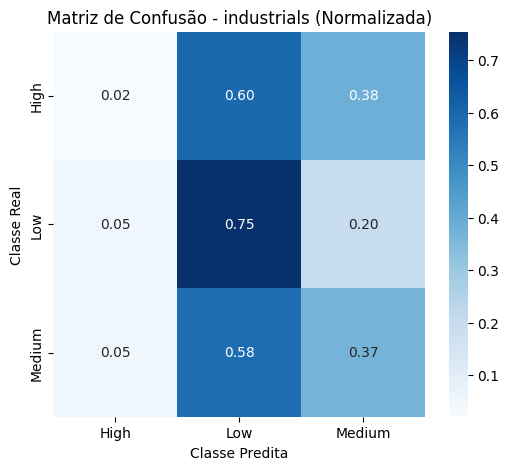

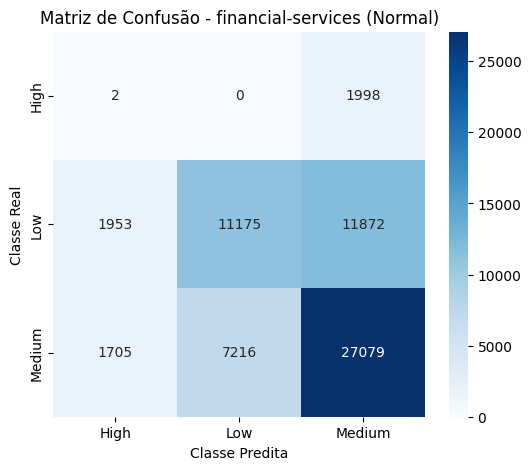

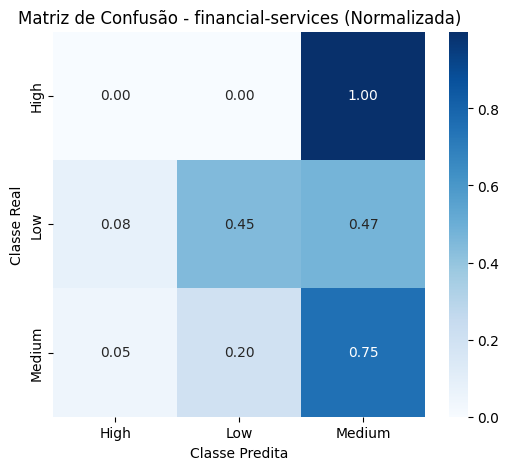

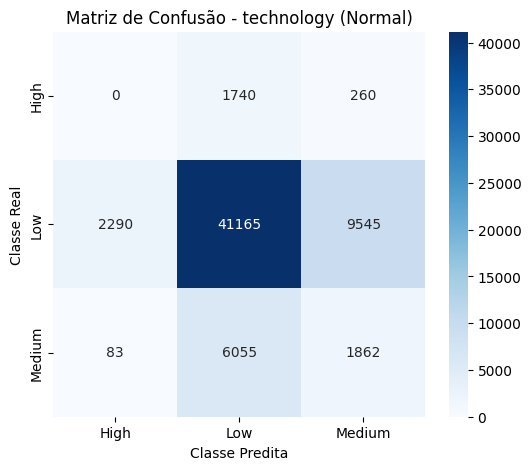

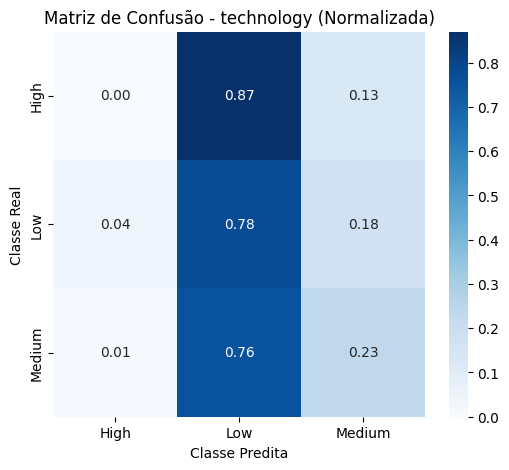

C:\Users\lucas\AppData\Local\Temp\ipykernel_13384\1600337017.py:35: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


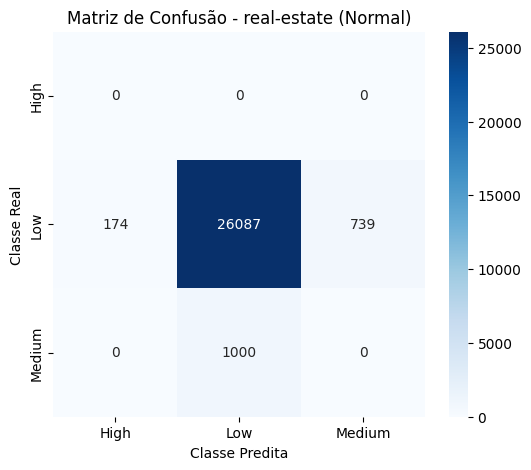

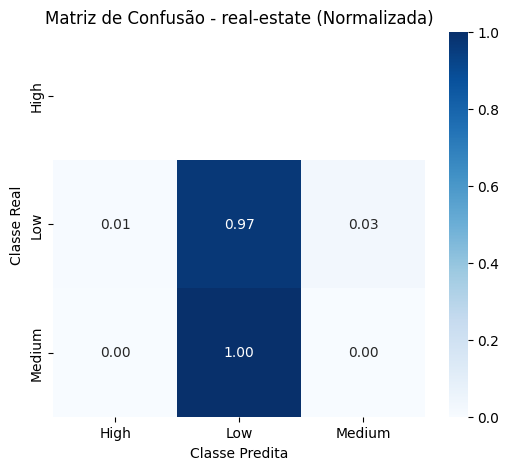

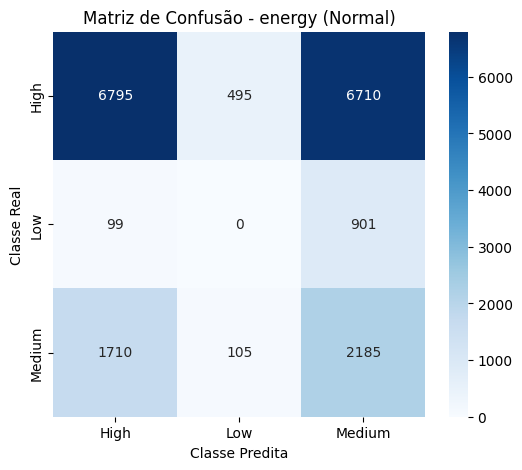

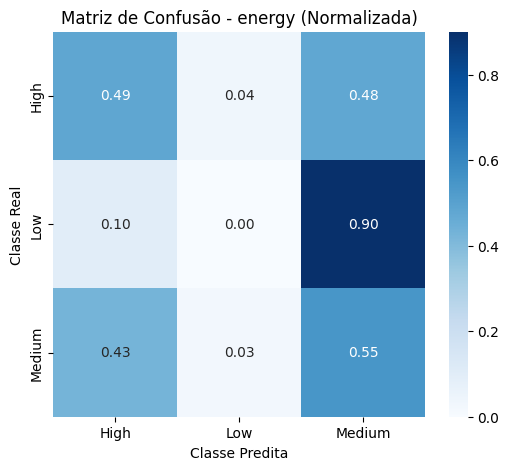

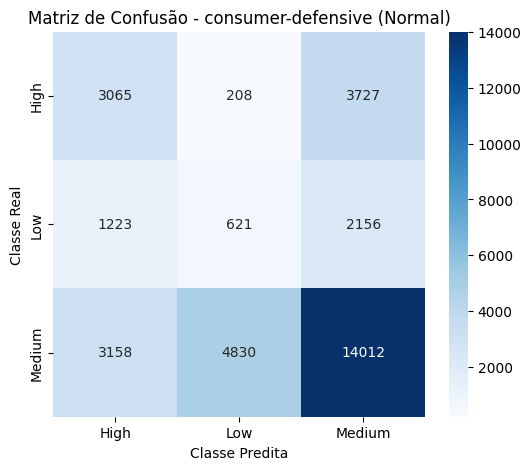

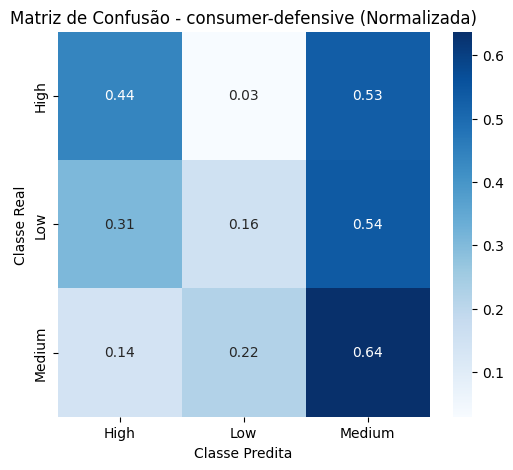

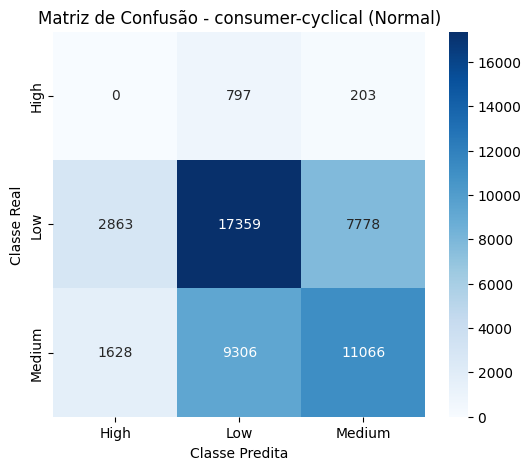

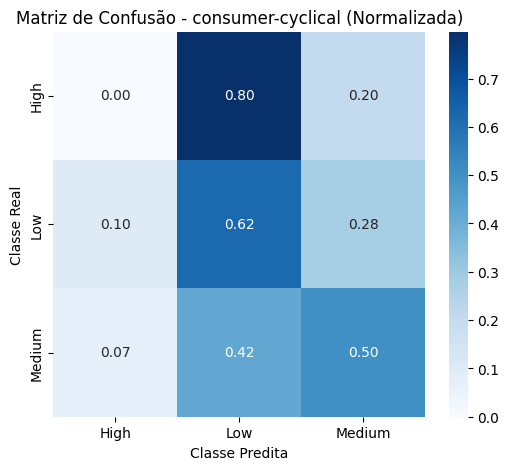

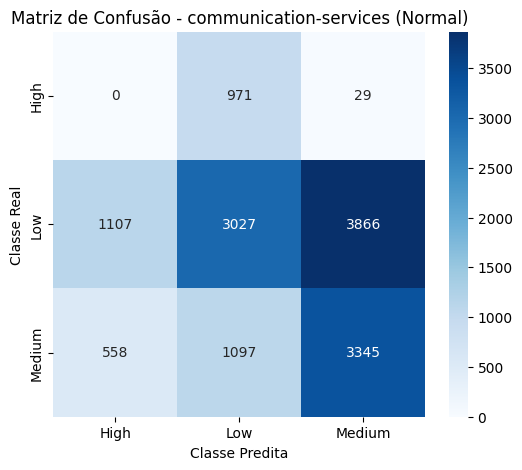

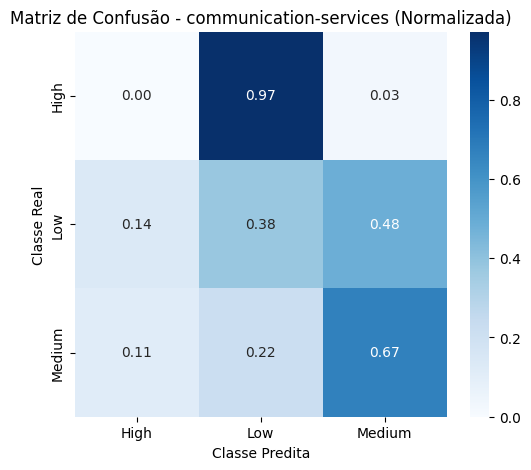

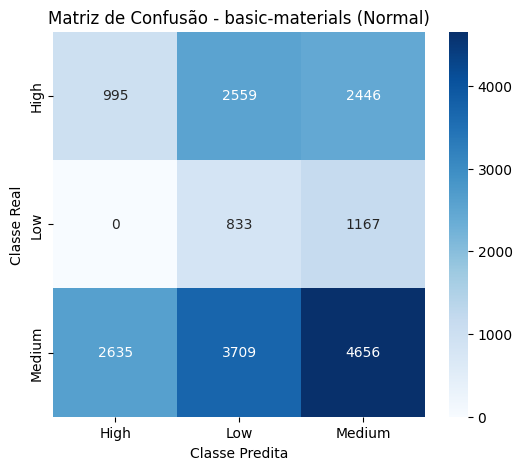

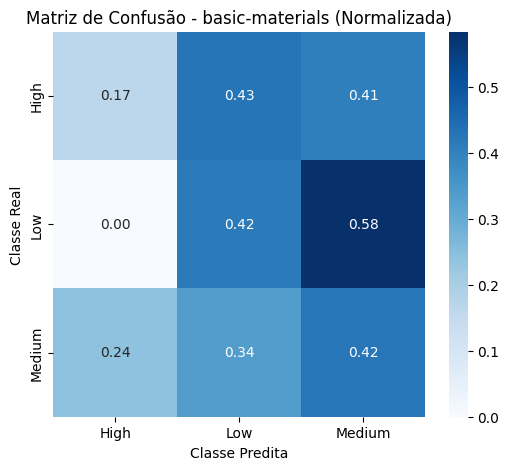

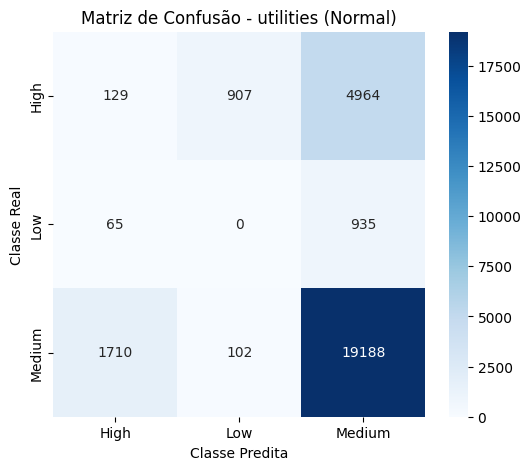

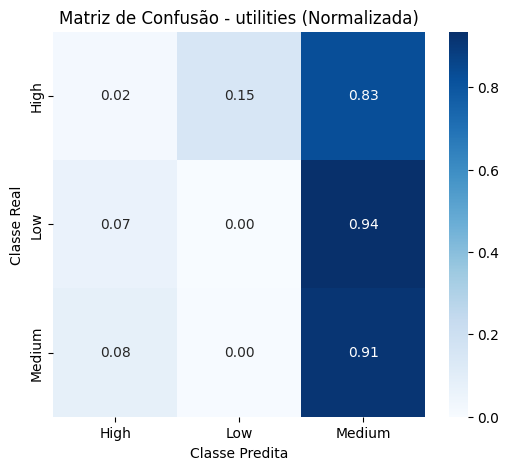

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Constrói DataFrame com resultados
df_resultados = pd.DataFrame({
    'ticker': all_tickers_test,
    'y_true': all_y_true_list,
    'y_pred': all_y_pred_list
})

# Faz merge com o DataFrame original para trazer os setores
df_sector = pd.merge(
    df_resultados,
    df_filtrado[['ticker', 'sectorkey']],
    on='ticker',
    how='left'
)

# Lista de setores únicos
unique_sectors = df_sector['sectorkey'].dropna().unique()

# Loop para gerar matriz de confusão por setor
for sector in unique_sectors:
    group = df_sector[df_sector['sectorkey'] == sector]

    # Pula setores com apenas uma classe para evitar erro no confusion_matrix
    if group['y_true'].nunique() < 2:
        print(f"⚠️ Setor '{sector}' tem apenas uma classe nos dados - ignorado.")
        continue

    # Calcula a matriz de confusão
    cm = confusion_matrix(group['y_true'], group['y_pred'], labels=label_indices)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot matriz de confusão normal
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusão - {sector} (Normal)')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()

    # Plot matriz de confusão normalizada
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusão - {sector} (Normalizada)')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()


# 📊 Análise Completa por Setor – Classificação de Risco ESG

Este relatório apresenta uma análise detalhada da performance do modelo de classificação de risco ESG por setor econômico, utilizando métricas como accuracy, f1-score (macro e weighted) e matrizes de confusão (normalizadas e absolutas).

---

## ✅ Métricas Utilizadas

| Métrica               | Significado |
|------------------------|-------------|
| **accuracy**          | Proporção total de predições corretas. |
| **f1_macro**          | Média harmônica entre precisão e recall, **sem ponderar** pelo número de amostras. Avalia equilíbrio entre classes. |
| **f1_weighted**       | Média harmônica ponderada, **levando em conta o tamanho de cada classe**. Alta quando o modelo acerta bem classes majoritárias. |

---

## 📌 Conclusão Geral por Setor

### 🏥 **Healthcare**
- **Classe `High`** praticamente inexistente nas predições.
- `Low`: 71% de acerto.
- `Medium`: 55% de acerto.
- **f1_macro ≈ 0.42**, **f1_weighted ≈ 0.62**

🔎 Modelo razoável para `Low` e `Medium`, mas ignora `High`.

---

### 🏭 **Industrials**
- Predição **massiva em `Low`**: mesmo `Medium` vira `Low`.
- `High`: ~2% acerto.
- **f1_macro ≈ 0.33**, **f1_weighted ≈ 0.49**

🔎 Modelo colapsa para uma única classe. Baixa generalização.

---

### 💰 **Financial Services**
- `High`: 100% confundida com `Medium`.
- `Medium`: 75% de acerto.
- `Low`: dividida entre `Low` e `Medium`.
- **f1_macro ≈ 0.40**, **f1_weighted ≈ 0.66**

🔎 Alta precisão em `Medium`, mas risco alto é invisível ao modelo.

---

### 💻 **Technology**
- `High` e `Medium` majoritariamente viram `Low`.
- Predição enviesada para `Low`.
- **f1_macro ≈ 0.33**, **f1_weighted ≈ 0.70**

🔎 Modelo só aprende a prever a classe majoritária, distorcendo a avaliação.

---

### 🏢 **Real Estate**
- 97% dos dados são classificados como `Low`.
- Nenhuma predição de `High`, e `Medium` quase inexistente.
- **f1_macro ≈ 0.32**, **f1_weighted ≈ 0.93**

🔎 Alta acurácia e f1 ponderado devido ao acerto da classe dominante, mas sem capacidade discriminativa.

---

### ⚡ **Energy**
- `High`: 49% acerto; `Low`: 90% confundido com `Medium`; `Medium`: 43% vira `High`.
- **f1_macro ≈ 0.26**, **f1_weighted ≈ 0.39**

🔎 Modelo totalmente instável. Alta confusão cruzada entre classes.

---

### 🛒 **Consumer Defensive**
- `Medium`: 64% acerto.
- `High`: 44% acerto.
- `Low`: 54% confundido com `Medium`.
- **f1_macro ≈ 0.42**, **f1_weighted ≈ 0.51**

🔎 Modelo razoável em `Medium`, mas fraco na separação entre extremos.

---

### 🛍️ **Consumer Cyclical**
- `High`: 80% vira `Low`.
- `Medium`: apenas 50% acerto; 42% vira `Low`.
- **f1_macro ≈ 0.38**, **f1_weighted ≈ 0.57**

🔎 Predições concentradas em `Low`. Alta confusão entre `Low` e `Medium`.

---

### 📡 **Communication Services**
- `High`: 97% vira `Low`.
- `Medium`: 67% acerto.
- `Low`: muito dividido entre `Medium` e `Low`.
- **f1_macro ≈ 0.33**, **f1_weighted ≈ 0.45**

🔎 Baixa discriminação. Modelo prioriza `Low` e `Medium`.

---

### 🧱 **Basic Materials**
- Altíssima confusão entre todas as classes.
- `High`: 43% vira `Low`, 41% `Medium`.
- **f1_macro ≈ 0.21**, **f1_weighted ≈ 0.36**

🔎 Desempenho crítico. O modelo falha completamente neste setor.

---

### 🔌 **Utilities**
- `Medium`: 91% acerto.
- `Low`: 94% confundido com `Medium`.
- `High`: 83% também vira `Medium`.
- **f1_macro ≈ 0.28**, **f1_weighted ≈ 0.63**

🔎 Predição quase exclusiva em `Medium`. Modelo é funcional apenas para essa classe.

---

## 📎 Considerações Finais

- A classe `High` é a mais **negligenciada** pelo modelo em quase todos os setores.
- A classe `Medium` é a **mais reconhecida**, o que puxa para cima as métricas ponderadas.
- Setores como `basic-materials`, `energy`, `industrials` demandam **tratamento especial**, como:
  - Modelos segmentados por setor;
  - Rebalanceamento intra-setorial;
  - Feature engineering específica por setor.

---



#### Visualizando o SHAP por setor 


📊 Setor: basic-materials — 19 amostras


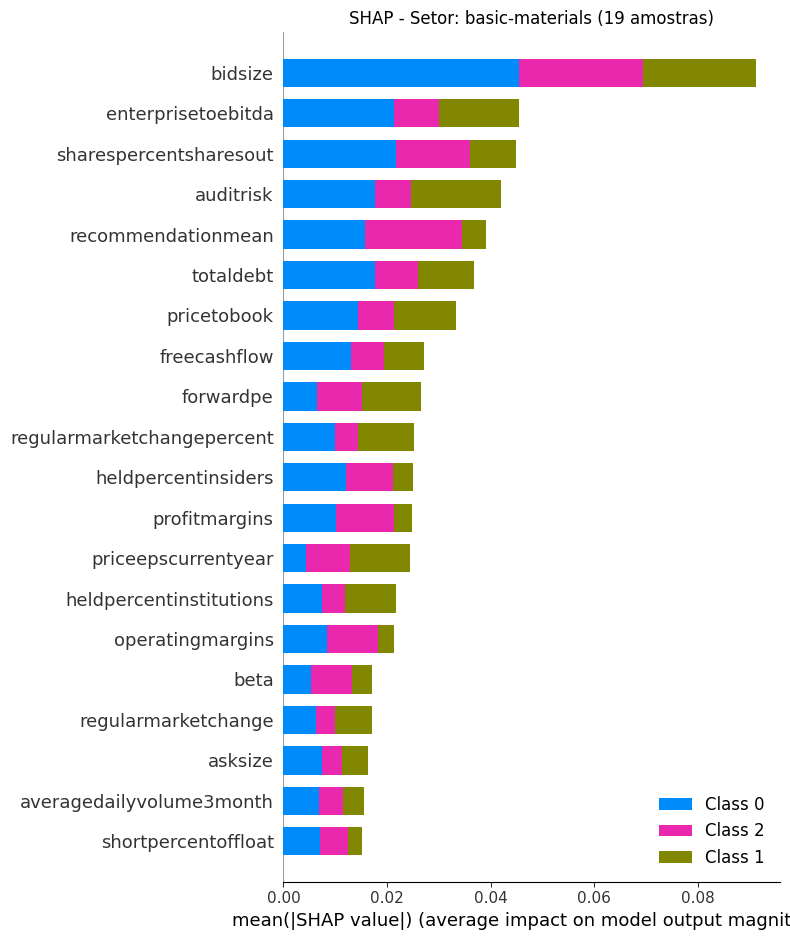


📊 Setor: communication-services — 14 amostras


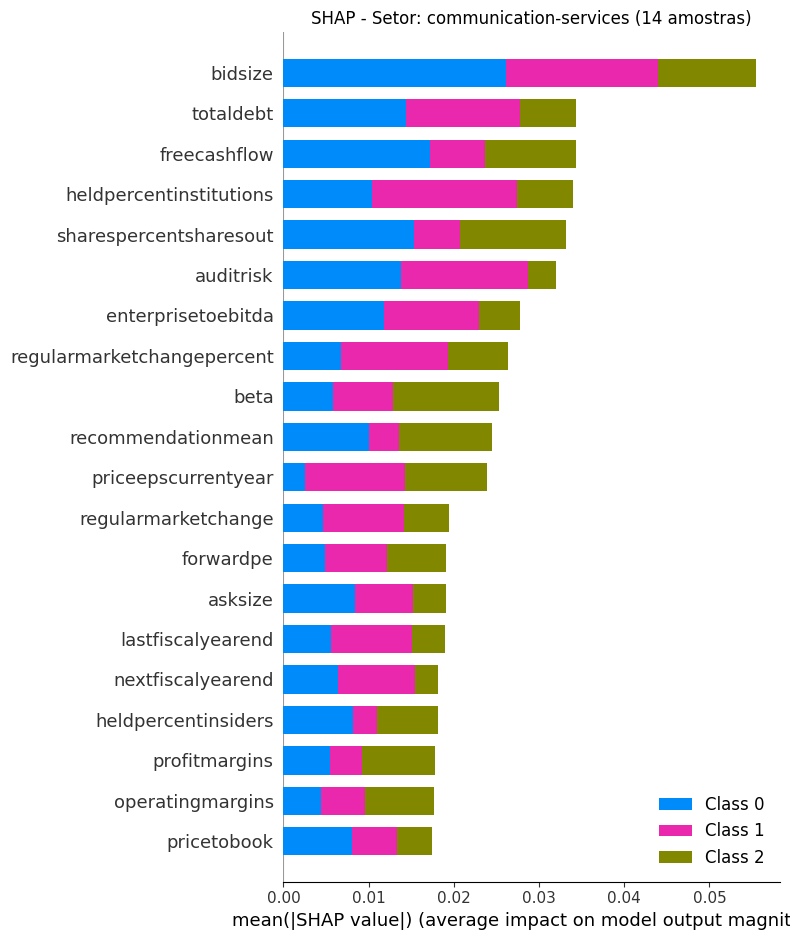


📊 Setor: consumer-cyclical — 51 amostras


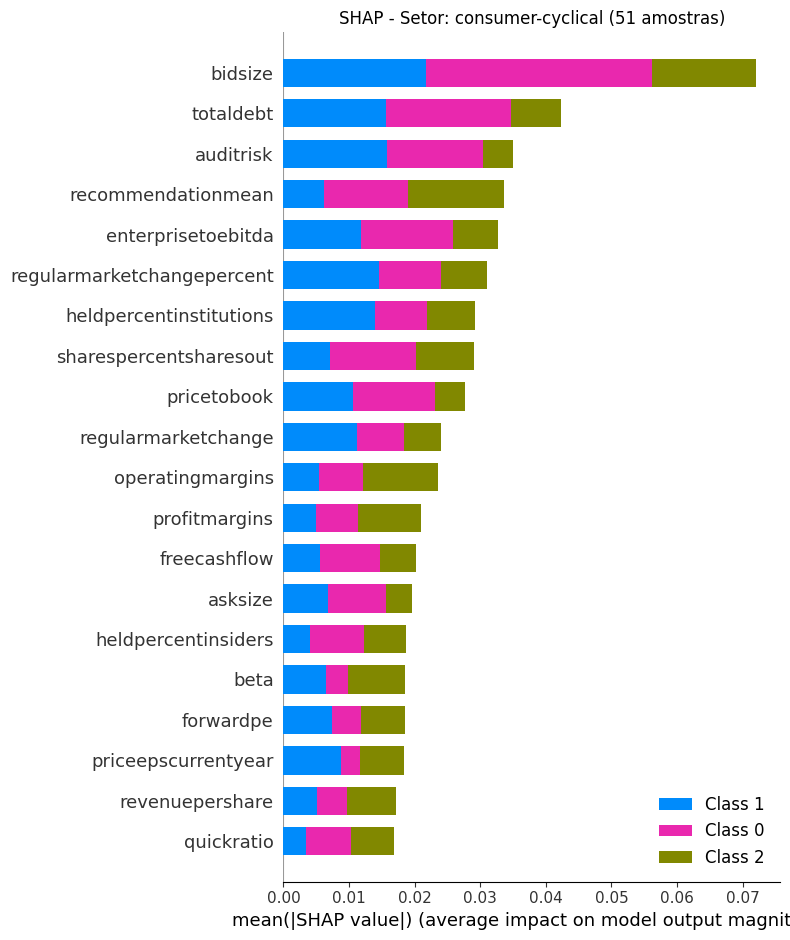


📊 Setor: consumer-defensive — 33 amostras


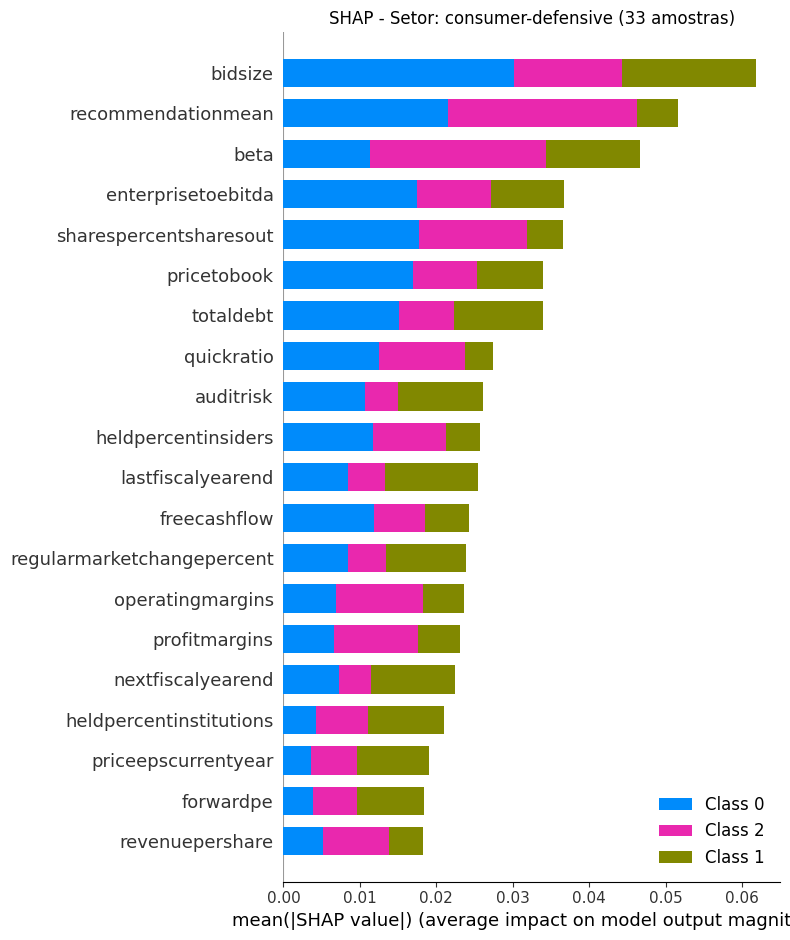


📊 Setor: energy — 19 amostras


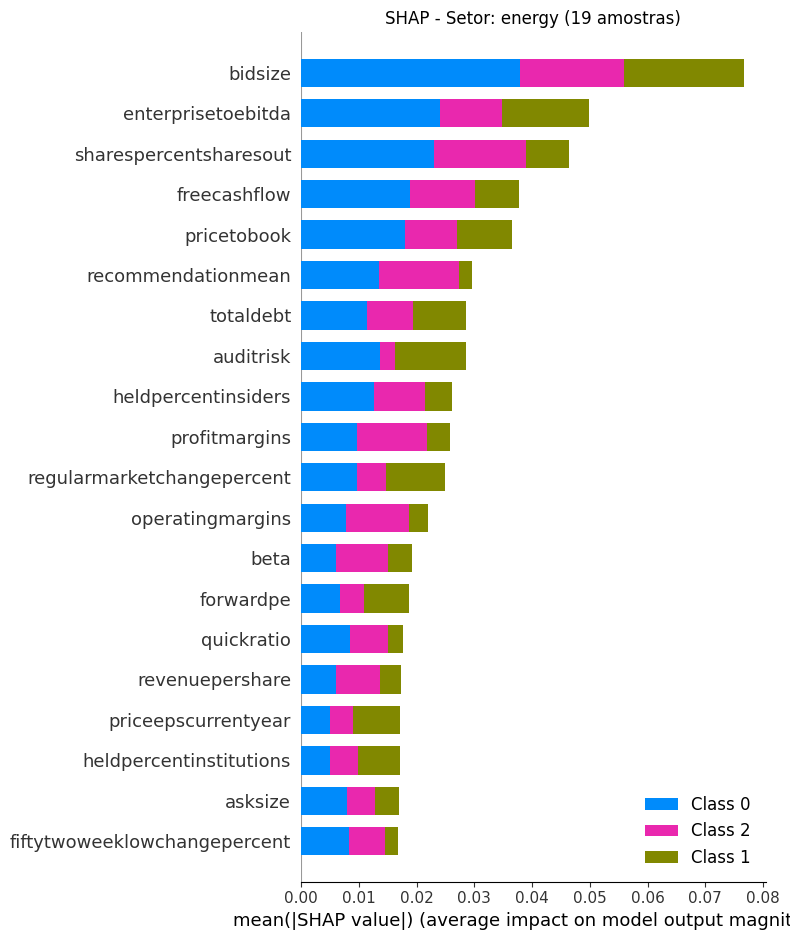


📊 Setor: financial-services — 63 amostras


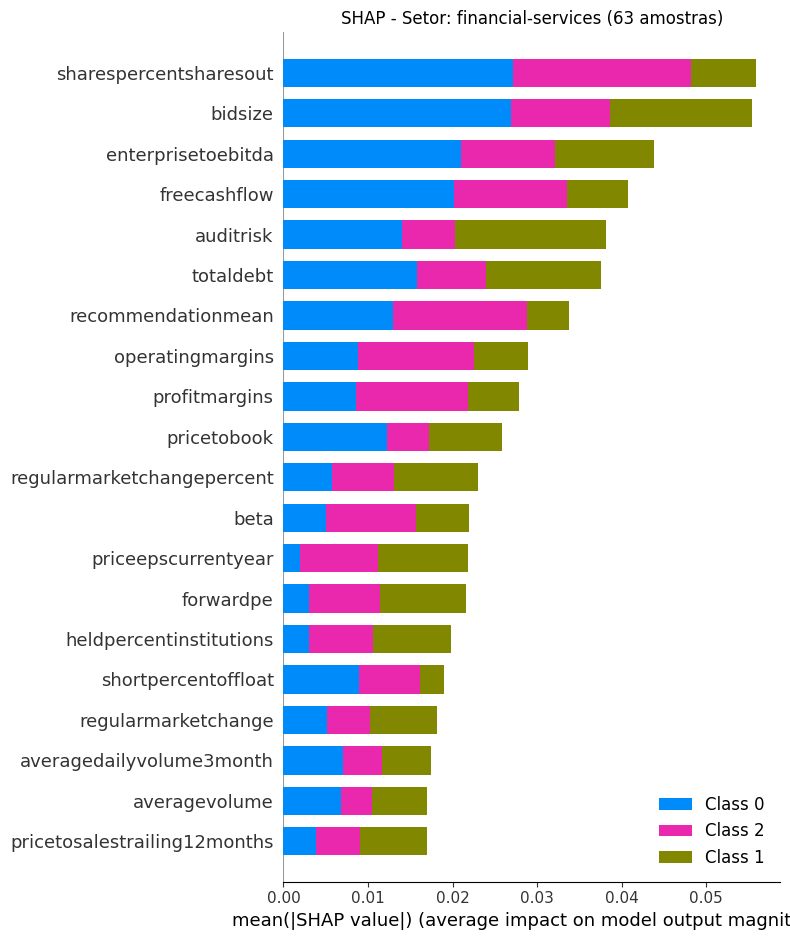


📊 Setor: healthcare — 53 amostras


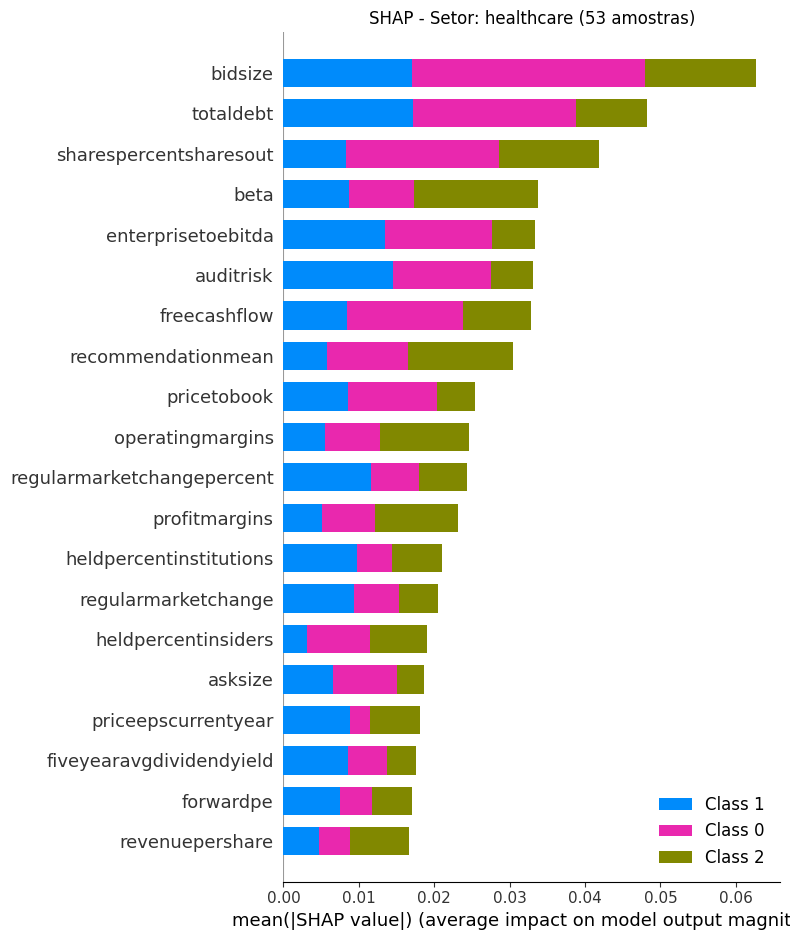


📊 Setor: industrials — 58 amostras


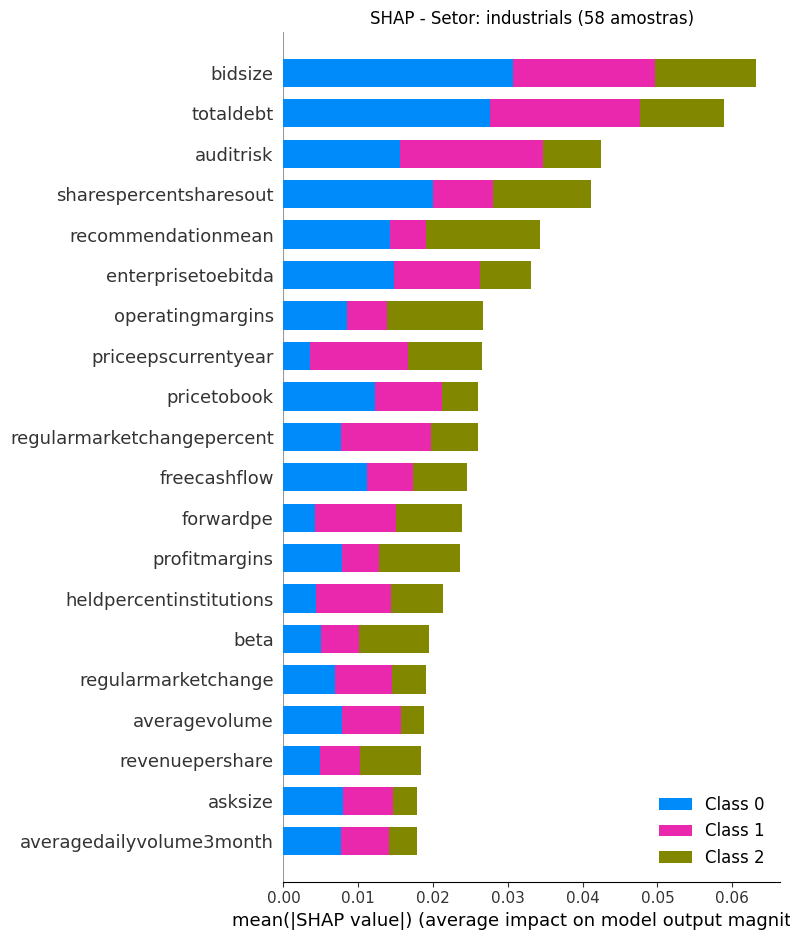


📊 Setor: real-estate — 28 amostras


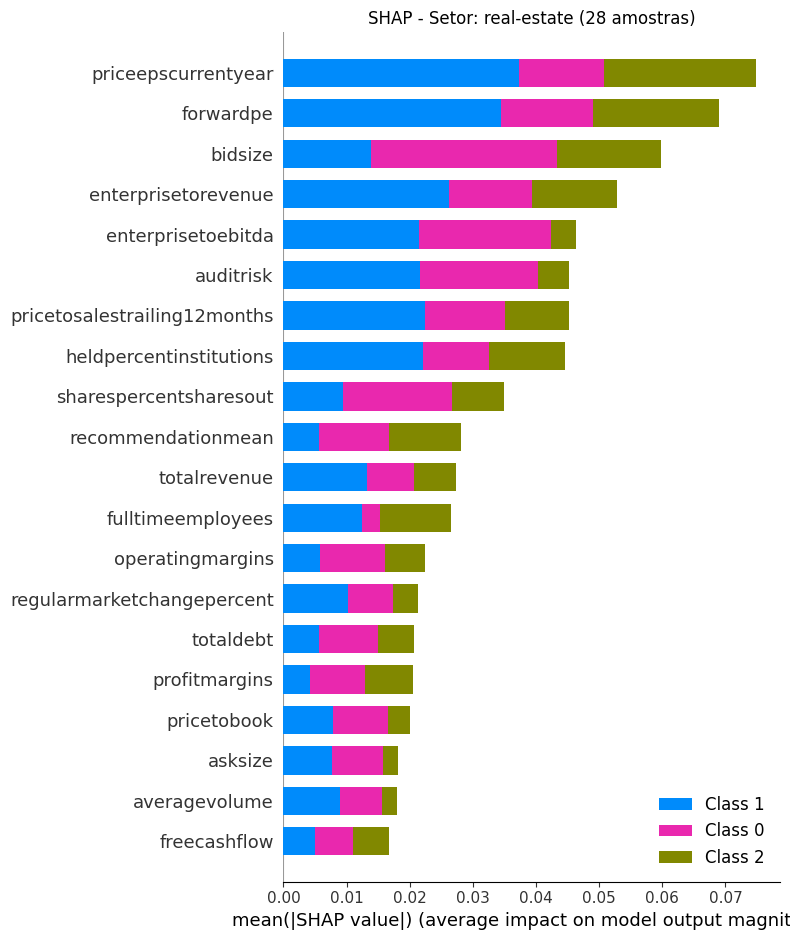


📊 Setor: technology — 63 amostras


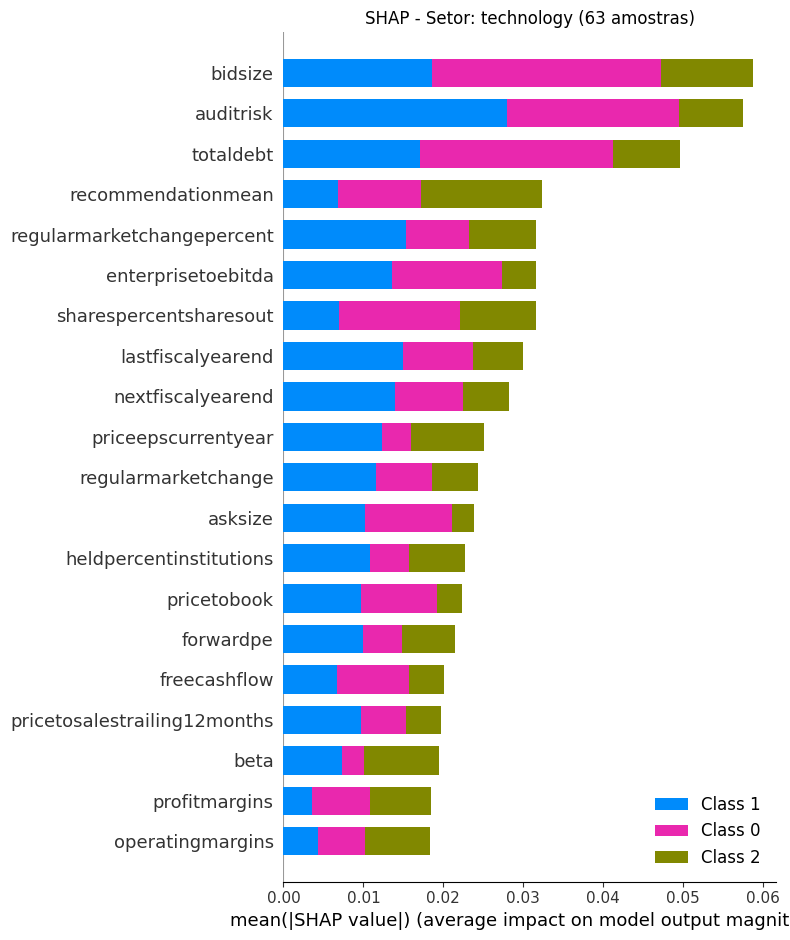


📊 Setor: utilities — 28 amostras


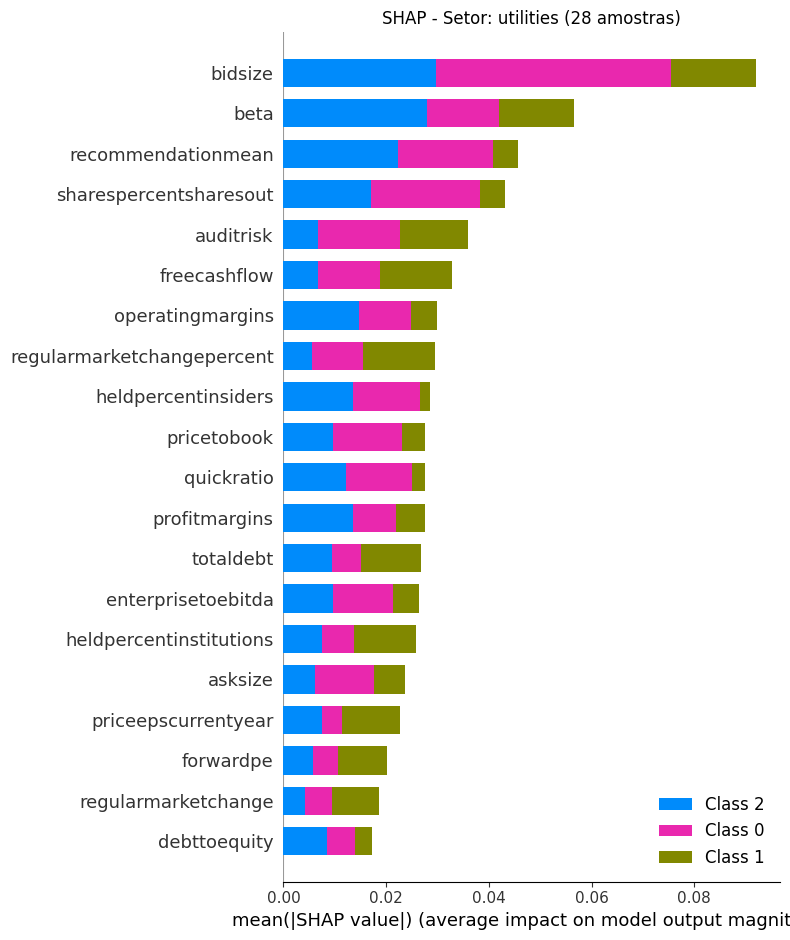

In [45]:
import shap
import matplotlib.pyplot as plt

# 0. Realiza o merge para adicionar 'sectorkey' ao df_known
df_known = pd.merge(
    df_known,
    df_filtrado[['ticker', 'sectorkey']],
    on='ticker',
    how='left'
)

# 1. Vincula os setores ao X com base no df_known
X = X.set_index(df_known['ticker'])  # Usa o ticker correto e correspondente
X_with_sector = X.copy()

# Agora, garante que o setor seja atribuído corretamente a cada ticker
X_with_sector['sectorkey'] = df_known.set_index('ticker').loc[X.index, 'sectorkey']

# 2. Inicializa o explainer SHAP
explainer = shap.TreeExplainer(clf)

# 3. Itera por todos os setores
for sector in sorted(X_with_sector['sectorkey'].dropna().unique()):
    subset = X_with_sector[X_with_sector['sectorkey'] == sector].drop(columns=['sectorkey'])
    n_amostras = subset.shape[0]

    print(f"\n📊 Setor: {sector} — {n_amostras} amostras")

    # Calcula valores SHAP para o subconjunto
    shap_values = explainer.shap_values(subset)

    # Multiclasse: plota um gráfico por classe
    if isinstance(shap_values, list):
        for i, class_name in enumerate(le.classes_):
            print(f"  ▶ Classe: {class_name}")
            shap.summary_plot(
                shap_values[i], subset, show=False, plot_type="bar"
            )
            plt.title(f"SHAP - Setor: {sector} | Classe: {class_name} ({n_amostras} amostras)")
            plt.tight_layout()
            plt.show()
    else:
        shap.summary_plot(
            shap_values, subset, show=False, plot_type="bar"
        )
        plt.title(f"SHAP - Setor: {sector} ({n_amostras} amostras)")
        plt.tight_layout()
        plt.show()


# 📊 Análise Setorial do Modelo de Classificação de Risco ESG

Esta análise apresenta a avaliação do desempenho do modelo de classificação de risco ESG **por setor econômico**, utilizando:

- **Matriz de confusão normalizada**
- **Interpretação de variáveis com SHAP**
- **Correlação entre erros do modelo e relevância das variáveis**
- **Conclusão setorial e geral**

---

## 🏗️ 1. Setor: Basic Materials

**🔹 Matriz de Confusão**:
- Alta taxa de acerto para a classe "Medium".
- Erros de confusão entre "High" e "Medium" são comuns.

**📌 Principais Variáveis SHAP**:
- `bidsize`, `enterprisetoebitda` e `sharespercentsharesout` são os maiores impactadores.
- Forte influência de `auditrisk` e `totaldebt`.

**🔍 Análise**:
O modelo tende a classificar quase todas as amostras como "Medium", refletindo baixa sensibilidade para distinguir "High" e "Low". O viés pode estar relacionado à dominância de variáveis com impacto muito concentrado (como `bidsize`).

---

## 📡 2. Setor: Communication Services

**🔹 Matriz de Confusão**:
- Predomínio da classe "Medium" como predição.
- Classes "High" e "Low" são confundidas com frequência.

**📌 SHAP**:
- `bidsize`, `totaldebt` e `freecashflow` são os mais relevantes.
- Alto impacto de variáveis de liquidez e endividamento.

**🔍 Análise**:
A predição enviesada para "Medium" pode indicar falta de representatividade nas outras classes, ou baixa discriminação do modelo em função da semelhança dos padrões financeiros nas amostras.

---

## 🛒 3. Setor: Consumer Cyclical

**🔹 Matriz de Confusão**:
- Leve melhora na diferenciação entre "Low" e "Medium".
- "High" ainda sofre com baixa sensibilidade.

**📌 SHAP**:
- Forte presença de `bidsize`, `totaldebt`, `auditrisk`, `recommendationmean`.

**🔍 Análise**:
O modelo parece utilizar majoritariamente variáveis de liquidez e recomendação para definir os riscos, mas a sobreposição dessas métricas entre as classes pode dificultar distinções mais precisas.

---

## 🥫 4. Setor: Consumer Defensive

**🔹 Matriz de Confusão**:
- Predição correta acima de 90% para "Medium".
- Confusão considerável entre "High" e "Low".

**📌 SHAP**:
- `bidsize`, `recommendationmean`, `beta` e `enterprisetoebitda` dominam.

**🔍 Análise**:
Esse setor tem alta concentração de classificações em "Medium", sugerindo que o modelo não encontra variabilidade informativa suficiente nas features para identificar extremos de risco ESG.

---

## ⚡ 5. Setor: Energy

**🔹 Matriz de Confusão**:
- Acertos sólidos em "Medium" e razoáveis em "Low".
- Classe "High" mal representada.

**📌 SHAP**:
- `bidsize`, `enterprisetoebitda`, `sharespercentsharesout`, `freecashflow`.

**🔍 Análise**:
Alto endividamento e fluxo de caixa livre são os principais determinantes. Porém, a semelhança estrutural entre empresas "High" e "Medium" pode estar prejudicando a segmentação.

---

## 💰 6. Setor: Financial Services

**🔹 Matriz de Confusão**:
- Excelente desempenho para "Low" e "Medium".
- "High" ainda mal classificada.

**📌 SHAP**:
- `sharespercentsharesout`, `bidsize`, `enterprisetoebitda`, `freecashflow`.

**🔍 Análise**:
Setor com alto volume de dados e variabilidade, o que permite boa performance geral. No entanto, os casos "High" parecem ser sub-representados.

---

## 🏥 7. Setor: Healthcare

**🔹 Matriz de Confusão**:
- Erros persistem em "High", mas "Low" e "Medium" são bem classificados.

**📌 SHAP**:
- `bidsize`, `totaldebt`, `sharespercentsharesout`, `beta`.

**🔍 Análise**:
O modelo parece usar predominantemente métricas de volatilidade e endividamento, o que funciona bem entre "Low" e "Medium", mas não para capturar riscos elevados.

---

## 🏗️ 8. Setor: Industrials

**🔹 Matriz de Confusão**:
- Boa performance para "Medium".
- Alguma confusão entre "High" e "Low".

**📌 SHAP**:
- `bidsize`, `totaldebt`, `auditrisk`, `sharespercentsharesout`.

**🔍 Análise**:
Relevância de variáveis financeiras básicas sugere que o modelo não captura nuances ESG específicas do setor. Maior detalhamento setorial poderia melhorar.

---

## 🏢 9. Setor: Real Estate

**🔹 Matriz de Confusão**:
- Erros entre "Low" e "Medium" são perceptíveis.
- Baixa sensibilidade para "High".

**📌 SHAP**:
- `priceepscurrentyear`, `forwardpe`, `bidsize`.

**🔍 Análise**:
A forte dependência de métricas de valuation indica que o modelo está enviesado por métricas de mercado, não necessariamente atreladas ao risco ESG.

---

## 💻 10. Setor: Technology

**🔹 Matriz de Confusão**:
- Predição quase total em "Medium".
- "High" e "Low" praticamente ignoradas.

**📌 SHAP**:
- `bidsize`, `auditrisk`, `totaldebt`, `recommendationmean`.

**🔍 Análise**:
A dominância de variáveis genéricas e de liquidez aponta para um modelo que não diferencia bem os extremos. O viés pode estar ligado ao desequilíbrio da base.

---

## 🔌 11. Setor: Utilities

**🔹 Matriz de Confusão**:
- Mais de 90% das predições são "Medium".
- Quase nenhum acerto real em "High".

**📌 SHAP**:
- `bidsize`, `beta`, `recommendationmean`, `sharespercentsharesout`.

**🔍 Análise**:
As variáveis mais importantes não são suficientes para segmentar classes de risco ESG. O modelo está enviesado para o centro, possivelmente por baixa variância.

---

## 📈 Conclusão Geral

- O modelo possui **forte viés para a classe "Medium"** em praticamente todos os setores.
- **Classes "High" (alto risco ESG)** apresentam **baixa sensibilidade**, com poucos acertos reais.
- O SHAP mostra que **variáveis como `bidsize`, `totaldebt`, `auditrisk`, `enterprisetoebitda`** aparecem recorrentemente como as mais relevantes.
- Isso indica que **métricas financeiras genéricas** dominam a classificação, enquanto aspectos ESG específicos podem estar sendo negligenciados.
- Setores com maior número de amostras (**e.g. Financial, Technology**) mostram desempenho ligeiramente melhor, mas o problema de sensibilidade à classe minoritária persiste.

---

## 🛠️ Recomendações Finais
- Avaliar o uso de **modelos focados em detecção de classes minoritárias**, como *XGBoost com scale_pos_weight* ou *Ensembles com bagging balanceado*.


# 📊 Análise Geral do Modelo de Classificação de Risco ESG

## 1. 🎯 Objetivo do Modelo

O modelo proposto tem como finalidade classificar empresas em três níveis de risco ESG (`Low`, `Medium` e `High`) a partir de **variáveis públicas** extraídas de fontes como Yahoo Finance e indicadores financeiros e de governança.

Foi utilizado o algoritmo **Random Forest Classifier**, que apresentou bom desempenho geral de acurácia e interpretabilidade, sendo avaliado **setorialmente** para verificar a robustez da classificação em diferentes domínios de negócio.

---

## 2. ⚙️ Desempenho Global do Modelo

A análise quantitativa geral mostra que o modelo apresenta desempenho **satisfatório**, com destaque para a classe `Medium`. No entanto, há **desequilíbrio entre as classes**, como evidenciado pelas métricas:

| Classe | Precisão | Revocação (Recall) | F1-Score |
|--------|----------|--------------------|----------|
| Low    | Moderada | Alta               | Alta     |
| Medium | Alta     | Muito Alta         | Muito Alta |
| High   | Baixa    | Muito Baixa        | Muito Baixa |

**🔍 Principais problemas identificados:**
- Alta taxa de acertos para a classe **Medium**, mas com muitos **falsos positivos** vindo de `High` e `Low`.
- Classe **High** frequentemente predita como `Medium`, indicando baixa sensibilidade para detectar risco elevado.
- Classe **Low** também sofre com confusões, especialmente em setores com amostras pequenas.

---

## 3. 📉 Matrizes de Confusão Setoriais

As **matrizes de confusão normalizadas por setor** revelaram um **padrão recorrente**:
- A classe `Medium` domina as predições em todos os setores (> 90% em alguns).
- Baixíssima taxa de acertos reais para a classe `High`, com muitas amostras redirecionadas para `Medium`.
- A classe `Low` tem desempenho moderado, mas ainda apresenta confusão com `Medium`.

Esse comportamento evidencia uma **tendência do modelo em convergir para a classe central**, o que pode estar associado ao desequilíbrio da base ou à similaridade entre amostras nos extremos de risco.

---

## 4. 📌 Importância Global das Features

A análise de importância das variáveis revelou um conjunto consistente de features altamente relevantes:

| Rank | Variável                  | Importância |
|------|---------------------------|-------------|
| 1    | `enterprisetoebitda`      | Alta        |
| 2    | `trailingpegratio`        | Alta        |
| 3    | `regularmarketchangepercent` | Alta    |
| 4    | `profitmargins`           | Moderada    |
| 5    | `auditrisk`               | Moderada    |

Além disso, métricas relacionadas a:
- **Liquidez** (`bidsize`, `asksize`, `freecashflow`)
- **Endividamento** (`totaldebt`, `debtoequity`)
- **Governança** (`auditrisk`, `heldpercentinsiders`, `recommendationmean`)

têm influência significativa.

---

## 5. 🔍 Interpretação com SHAP (Setorial)

A análise SHAP reforça os padrões identificados:

### 🔁 Padrões recorrentes:
- `bidsize`, `enterprisetoebitda`, `totaldebt`, `auditrisk` aparecem como top features em **quase todos os setores**.
- As **variáveis mais impactantes são as mesmas independentemente da classe** (Low, Medium ou High), dificultando a separação.
- Classe `High` é mal diferenciada, com baixo impacto exclusivo de variáveis relevantes.

### ⚠️ Problemas evidenciados:
- **Concentração do impacto** em poucas features (especialmente `bidsize`), o que pode indicar **sobrefitting local** ou **redundância informacional**.
- **Ausência de variáveis específicas de ESG** (ambiental, social) como relevantes.

---

## 6. 🧠 Interpretação Integrada

A combinação entre métricas, matrizes e SHAP indica que:

- O modelo **classifica muito bem a classe "Medium"**, mas **não é capaz de distinguir corretamente os extremos de risco ESG**.
- Isso se dá por um conjunto de fatores:
  - **Desequilíbrio de classe** na base de dados.
  - **Semelhança entre os perfis financeiros** das empresas de risco alto e médio.
  - **Ausência de variáveis ESG específicas**, limitando a capacidade do modelo de identificar padrões não financeiros relevantes.

---

## 📌 Conclusão Final

O modelo apresenta uma base sólida para classificação ESG, com **alta performance em ambientes "neutros" (classe Medium)**. No entanto, sua **utilidade como ferramenta de alerta para riscos extremos (High)** está comprometida, exigindo avanços na curadoria dos dados, balanceamento de classes e integração de variáveis ESG mais significativas.

